<a href="https://colab.research.google.com/github/BeatriceCamera/SocialMediaAnalysis_project/blob/main/WSA_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Framing AI in the Hollywood Strike: A Social Media Analysis of Online Communities**

*Beatrice Camera 535313, Daria Miele 535702*

In 2023, the American entertainment industry was brought to a near-complete standstill by a historic double labor dispute. The Writers Guild of America (WGA) officially went on strike on May 2, 2023, after failing to reach an agreement with the Alliance of Motion Picture and Television Producers (AMPTP) on compensation, residuals, and working conditions.  SAG-AFTRA, the union representing approximately 160,000 actors, performers, and media professionals, joined the strike on July 14, 2023, following the expiration of its contract with the AMPTP.  The joint action marked the first time writers and actors had struck simultaneously since 1960.

At the center of both disputes was the rapid rise of generative AI. One of the most significant obstacles in negotiations was the use of artificial intelligence by major studios, particularly concerns over AI being used to duplicate an actor's likeness, raising compensation and creative ownership dilemmas.  Writers raised parallel concerns about studios using AI to generate or modify scripts, potentially reducing the size of writing rooms and undermining authorship rights. The WGA agreement, reached on September 26, included wage increases, improved streaming residuals, and explicit protections against the use of AI.  SAG-AFTRA reached its own tentative agreement on November 8, 2023, with the contract formally ratified on December 5.

The 2023 Hollywood Strike represented a turning point in the public debate about AI and creative labor, the first major instance in which a large workforce collectively organized around the risks posed by generative AI to their livelihoods. This makes it a particularly relevant case for social media analysis: the dispute generated intense, sustained, and ideologically diverse online discussion across a wide range of communities.

**Sources:** Wikipedia, *2023 Hollywood Labor Disputes*; World Economic Forum, *AI and Hollywood: 5 questions for SAG-AFTRA's chief negotiator* (2024); Statista, *SAG-AFTRA and WGA Strikes: Statistics & Facts*; Entertainment Tonight, *SAG-AFTRA and WGA Strikes: All the Major Dates to Know* (2023).

### **Research Question**: How did online communities frame the role of AI during the Hollywood Strike, and did framing vary systematically across communities and across the temporal phases of the dispute?


## **Table of Contents**

**Section 0: Setup**
Library installation, imports, and Google Drive configuration.

**Section 1: Data Collection.**
Reddit submissions and comments are collected via the PullPush historical archive. The collection is organized around a structured query log covering five analytical frames: replacement anxiety, workers' rights, authenticity and creativity, corporate power, and innovation. Each post and comment is assigned to one of three temporal phases: pre-strike, strike, and post-strike, to support longitudinal comparison.

**Section 2: Preprocessing.**
The raw corpus is cleaned and standardized before analysis. This includes relevance filtering to remove off-topic submissions, removal of deleted and automated content, language filtering to retain only English posts, and a full NLP pipeline consisting of text normalization, tokenization, stopword removal with custom domain-specific extensions, and lemmatization. The same pipeline is applied to both posts and comments.

**Section 3: Exploratory Content Analysis.**
The cleaned corpus is explored through word frequency analysis, bigram extraction, and vocabulary comparison across subreddits and temporal phases. This exploratory stage identifies the most prominent lexical patterns in the corpus and provides preliminary evidence that different communities use distinct vocabularies when discussing AI during the Hollywood Strike.

**Section 4: Frame Detection.**
Building on the exploratory analysis, a set of five theory-driven frame dictionaries is defined and applied to classify each post and comment according to its dominant AI framing: replacement anxiety, workers' rights, authenticity and creativity, corporate power, and innovation and opportunity. Frame distributions are compared across subreddits and temporal phases to provide a first direct answer to the research question.

**Section 5: Network Analysis.** A reply interaction network is constructed from the cleaned comments dataset, where nodes represent Reddit users and directed edges represent reply interactions. Centrality measures (degree, betweenness, closeness) are computed to identify the most structurally important users, with betweenness centrality used to profile broker users. Community detection is performed using the Louvain algorithm, and community profiles are examined to assess alignment with subreddit boundaries. The temporal evolution of the network is analyzed across the three phases through modularity comparison, cross-subreddit edge proportion, and degree assortativity.

**Section 6: Content Analysis.** Sentiment analysis is applied to the cleaned submissions corpus using a transformer-based model pre-trained on social media text. Sentiment scores are computed for each post and compared across subreddits and temporal phases to assess whether the emotional valence of AI-related discourse changed during the strike. Named Entity Recognition (NER) is then applied to identify the most frequently mentioned organizations, persons, and technologies across communities, providing complementary evidence about which actors and institutions were most central to the debate.

**Section 7: Intergration.** The structural and content dimensions of the analysis are brought together by mapping network communities against frame labels, sentiment scores, and entity annotations. Frame distributions are examined across detected communities to assess whether structurally distinct clusters also differ in their interpretive orientation toward AI. The relationship between betweenness centrality and framing diversity is explored as a secondary question. This section provides the final, unified answer to the research question.

## **0. Setup**

In [ ]:
!pip install pandas requests tqdm matplotlib
!pip install pandas spacy langdetect
!python -m spacy download en_core_web_sm
!pip install networkx python-louvain
!pip install pyvis -q
!pip install transformers torch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=83d0ec6634e1b15939337754f1dbeac6c9df74233065bb36ccec2b9e2dffddc9
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 57.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.0 MB/s eta 0:00:00


In [ ]:
from collections import defaultdict, Counter
from datetime import datetime
import os
import re
import string
import time
from nltk.util import ngrams
import nltk

from IPython.display import display, HTML
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from tqdm import tqdm

from langdetect import detect, LangDetectException
import spacy
from transformers import pipeline
from wordcloud import WordCloud

import community.community_louvain as community_louvain
import networkx as nx
from pyvis.network import Network

nlp = spacy.load("en_core_web_sm")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Output directory on Google Drive
DRIVE_PATH = '/content/drive/MyDrive/WSA_Camera_Miele/data/'
DRIVE_PATH_IMAGES = '/content/drive/MyDrive/WSA_Camera_Miele/figures/'
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(DRIVE_PATH_IMAGES, exist_ok=True)

print(f"Output path: {DRIVE_PATH}")
print(f"Output path: {DRIVE_PATH_IMAGES}")

Mounted at /content/drive
Output path: /content/drive/MyDrive/WSA_Camera_Miele/data/
Output path: /content/drive/MyDrive/WSA_Camera_Miele/figures/


In [ ]:
PRE_COLOR = "#E9692C"
STRIKE_COLOR = "#008080"
POST_COLOR = "#D1495B"
ACCENT_COLOR = "#F49AC2"
NEUTRAL_COLOR = "#6082B6"

In [ ]:
RUN_COLLECTION = False

POSTS_PATH = DRIVE_PATH + "submissions_raw.csv"
COMMENTS_PATH = DRIVE_PATH + "comments_raw.csv"

**Technical Note:** Data collection relies on PullPush, an independent third-party archive of Reddit posts maintained by volunteers. Unlike the official Reddit API, PullPush supports historical search with date filtering, making it suitable for retrospective analysis of a concluded event. However, PullPush is known to be intermittently unavailable: server-side failures return HTTP 502 errors (*Bad Gateway*), meaning the server did not respond, and the corresponding queries return zero results. To ensure reproducibility and protect against this instability, a `RUN_COLLECTION` flag is implemented. When set to `False`, the notebook skips the collection entirely and loads the frozen datasets saved to Google Drive during the original run. This guarantees that all results remain stable across re-runs, regardless of PullPush availability.

## **1. Data Collection and Configuration**

Here, we define the main parameters used for Reddit data collection through PullPush. The analysis covers the period from March to December 2023, so that the dataset includes the pre-strike discussion, the strike period, and the post-strike phase.

The selected subreddits represent different perspectives on the debate around AI and the Hollywood Strike:
* `r/Screenwriting`: professional screenwriters and industry insiders, directly affected by the strike and AI-related contractual disputes
* `r/movies`: general film audiences focused on cinema as a cultural product, discussing directors, storytelling, and the creative implications of AI
* `r/artificial`: technology-oriented users engaging with AI primarily as a tool for innovation and progress
* `r/television`: communities centered on serialized content, where concerns about AI were more directly tied to the continuity and quality of ongoing shows and the writers behind them
* `r/labor`: labor rights advocates discussing the strike within the broader context of workers' rights and collective bargaining

The query log combines broad search terms with more specific expressions related to the main analytical frames of the project: replacement anxiety, workers’ rights, authenticity and creativity, and pre-strike contractual negotiations. Keeping the full query log in the notebook makes the data collection process transparent and reproducible.

The PullPush parameters define the endpoint, the number of results requested for each query, the timeout for slow responses, and a short pause between requests to avoid overly aggressive collection.

In [ ]:
# Time window for the analysis
DATE_START = datetime(2023, 3, 1)
DATE_END = datetime(2023, 12, 31)

AFTER = int(DATE_START.timestamp())
BEFORE = int(DATE_END.timestamp())

# Phase boundaries
PHASE_STRIKE_START = datetime(2023, 5, 1)
PHASE_POSTSTRIKE_START = datetime(2023, 9, 1)

# Target subreddits
SUBREDDITS = [
    "Screenwriting",
    "movies",
    "artificial",
    "television",
    "labor",
]

# Search query log
QUERY_LOG = {
    "q01_broad_1": "Hollywood strike AI",
    "q02_broad_2": "WGA AI",
    "q03_broad_3": "SAG-AFTRA AI",
    "q04_broad_4": "writers strike AI",
    "q05_broad_5": "generative AI Hollywood",
    "q06_replacement_1": "AI actors",
    "q07_replacement_2": "AI writers",
    "q08_replacement_3": "replace writers AI",
    "q09_replacement_4": "replace actors AI",
    "q10_rights_1": "digital likeness",
    "q11_rights_2": "synthetic actors",
    "q12_rights_3": "AI clause strike",
    "q13_rights_4": "consent AI Hollywood",
    "q14_creativity_1": "AI creativity writers",
    "q15_creativity_2": "human writers AI",
    "q16_prestrike_1": "WGA negotiation AI",
    "q17_prestrike_2": "WGA contract AI",
    "q18_prestrike_3": "writers guild AI",
    "q19_prestrike_4": "AI Hollywood 2023",
}

# PullPush API settings
PULLPUSH_URL = "https://api.pullpush.io/reddit/search/submission/"
REQUEST_SIZE = 250
REQUEST_TIMEOUT = 30
REQUEST_SLEEP = 1

print("Configuration loaded.")
print(f"Period: {DATE_START.date()} → {DATE_END.date()}")
print(f"Subreddits: {SUBREDDITS}")
print(f"Queries: {len(QUERY_LOG)}")

Configuration loaded.
Period: 2023-03-01 → 2023-12-31
Subreddits: ['Screenwriting', 'movies', 'artificial', 'television', 'labor']
Queries: 19


The collection focuses on high-engagement submissions by sorting results according to score. This improves the quality of the dataset by prioritizing discussions that generated stronger interaction and visibility within the platform.

A temporal phase label is also assigned to each post. The dataset is divided into three analytical phases:
- pre-strike,
- strike,
- post-strike.

This temporal categorization is later used to compare the evolution of framing patterns, sentiment, and community structure across different moments of the Hollywood Strike.

In [ ]:
def fetch_submissions(query, subreddit, after, before, size, timeout):
    params = {
        "q": query,
        "subreddit": subreddit,
        "after": after,
        "before": before,
        "size": size,
        "sort": "desc",
        "sort_type": "score",
    }

    try:
        response = requests.get(
            PULLPUSH_URL,
            params=params,
            timeout=timeout
        )
        if response.status_code != 200:
            print(f"  [WARN] HTTP {response.status_code} — query='{query}', subreddit='{subreddit}'")
            return []
        return response.json().get("data", [])

    except requests.exceptions.Timeout:
        print(f"  [WARN] Timeout — query='{query}', subreddit='{subreddit}'")
        return []

    except Exception as e:
        print(f"  [ERROR] {e} — query='{query}', subreddit='{subreddit}'")
        return []

def assign_phase(date):
    if date is None:
        return "unknown"
    if date < PHASE_STRIKE_START:
        return "pre-strike"
    elif date < PHASE_POSTSTRIKE_START:
        return "strike"
    else:
        return "post-strike"

print("Helper functions defined.")

Helper functions defined.


The collection loop systematically searches each target subreddit using every query defined in the query log. For each retrieved submission, the code stores all metadata required for the subsequent stages of the project:
- textual content for framing and sentiment analysis,
- author information for network construction,
- timestamps for temporal analysis,
- engagement metrics such as score and number of comments,
- query identifiers for reproducibility and transparency.

The resulting dataset represents the raw submissions corpus before preprocessing and deduplication.

In [ ]:
if RUN_COLLECTION:
    print("Collecting submissions from PullPush...")
    all_posts = []
    for subreddit in SUBREDDITS:
        print(f"\nCollecting from r/{subreddit}")
        for qkey, query in tqdm(QUERY_LOG.items(), desc=f"r/{subreddit}"):
            results = fetch_submissions(
                query=query,
                subreddit=subreddit,
                after=AFTER,
                before=BEFORE,
                size=REQUEST_SIZE,
                timeout=REQUEST_TIMEOUT,
            )
            for post in results:
                all_posts.append({
                    "id":           post.get("id"),
                    "subreddit":    post.get("subreddit"),
                    "query_key":    qkey,
                    "query":        query,
                    "title":        post.get("title"),
                    "text":         post.get("selftext", ""),
                    "author":       post.get("author"),
                    "score":        post.get("score"),
                    "upvote_ratio": post.get("upvote_ratio"),
                    "num_comments": post.get("num_comments"),
                    "permalink":    post.get("permalink"),
                    "url":          post.get("url"),
                    "date":         datetime.fromtimestamp(post.get("created_utc"))
                                    if post.get("created_utc") else None,
                })
            time.sleep(REQUEST_SLEEP)

    if len(all_posts) == 0:
        print("[WARN] Collection returned 0 posts. CSV not overwritten.")
        print("Loading existing dataset from Drive...")
        df = pd.read_csv(POSTS_PATH, parse_dates=["date"])
        print(f"Rows loaded: {len(df)}")
    else:
        df = pd.DataFrame(all_posts)
        df = df.drop_duplicates(subset="id").reset_index(drop=True)
        df.to_csv(POSTS_PATH, index=False)
        print(f"Saved {len(df)} unique posts to {POSTS_PATH}")
        print(f"Duplicates removed: {len(all_posts) - len(df)}")

else:
    print("RUN_COLLECTION = False → loading frozen dataset from Drive...")
    df = pd.read_csv(POSTS_PATH, parse_dates=["date"])
    print(f"Rows loaded: {len(df)}")

RUN_COLLECTION = False → loading frozen dataset from Drive...
Rows loaded: 399


Each post is assigned to one of the three temporal phases defined earlier. The dataset is then sorted chronologically to make later inspection easier.

A unified `full_text` column is also created by combining the title and body of each post. As matter of facts, many Reddit submissions contain most of their relevant content in the title, while others include longer discussion prompts in the body.

Before moving to preprocessing and analysis, the dataset is described through basic statistics. These values help assess the size, temporal coverage, subreddit distribution, author diversity, and engagement level of the collected corpus.

In [ ]:
df["phase"] = df["date"].apply(assign_phase)

df = df.sort_values("date").reset_index(drop=True)

df["full_text"] = df.apply(
    lambda row: row["title"] + " " + row["text"]
    if pd.notna(row["text"]) and str(row["text"]).strip() not in ["", "[deleted]", "[removed]"]
    else row["title"],
    axis=1
)

In [ ]:
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)

print(f"Total posts:              {len(df)}")
print(f"Time window:              {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique authors:           {df['author'].nunique()}")
print(f"Subreddits:               {df['subreddit'].nunique()}")

print("\nPosts per phase:")
print(df["phase"].value_counts().to_string())

print("\nPosts per subreddit:")
print(df["subreddit"].value_counts().to_string())

print("\nEngagement (num_comments):")
print(df["num_comments"].describe().round(1).to_string())

print("\nAverage comments per phase:")
print(df.groupby("phase")["num_comments"].mean().round(1).to_string())

print("\nAverage score per phase:")
print(df.groupby("phase")["score"].mean().round(1).to_string())

DATASET SUMMARY
Total posts:              399
Time window:              2023-03-02 → 2023-12-28
Unique authors:           239
Subreddits:               5

Posts per phase:
phase
strike         199
post-strike    164
pre-strike      36

Posts per subreddit:
subreddit
movies           175
Screenwriting     96
artificial        76
television        47
labor              5

Engagement (num_comments):
count     399.0
mean       26.1
std       150.9
min         0.0
25%         0.0
50%         0.0
75%         5.0
max      2287.0

Average comments per phase:
phase
post-strike    16.4
pre-strike     19.0
strike         35.4

Average score per phase:
phase
post-strike     13.9
pre-strike      26.6
strike         213.9


The dataset comprises 399 unique Reddit submissions collected across five communities over a ten-month period (March–December 2023). The corpus includes 239 distinct authors, indicating a sufficiently diverse set of voices rather than a few dominant users.

The temporal distribution confirms that the strike period (May–August 2023) generated the highest discussion volume (199 posts), consistent with the real-world escalation of the labor dispute. The pre-strike phase is underrepresented (36 posts), which reflects both lower base activity during the negotiation period and partial archival gaps in PullPush for early 2023.  This limitation is acknowledged and does not affect the validity of the strike and post-strike comparisons.  

Engagement is highly skewed: the median number of comments per post is 0, while the maximum reaches 2287. This distribution is typical of social media corpora, where a small number of posts concentrate most of the interaction. The average score during the strike phase (213.9) is notably higher than in the post-strike phase (13.9), suggesting that discussions were more visible and contested when the labor dispute was active.

To evaluate whether the collected corpus accurately mirrors the real-world progression of public discourse, a monthly timeline analysis is conducted. A significant expansion in volume during the core strike months serves as a proxy to validate that the dataset captures the exact period when generative AI concerns reached their peak salience within the Hollywood labor dispute.

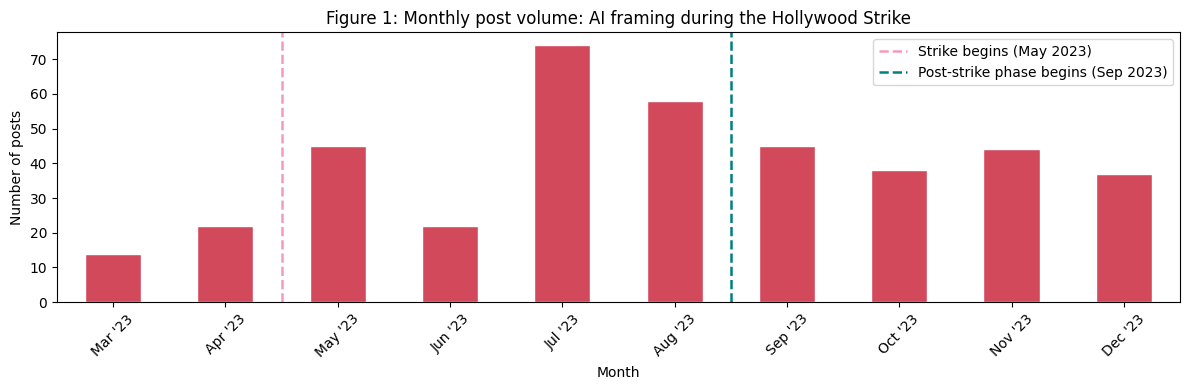

In [ ]:
df["month"] = df["date"].dt.to_period("M")
monthly = df.groupby("month").size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind="bar", ax=ax, color=POST_COLOR, edgecolor="white")

months_list = list(monthly.index.astype(str))

try:
    strike_start_idx = months_list.index("2023-05") - 0.5
    strike_end_idx = months_list.index("2023-09") - 0.5

    ax.axvline(
        x=strike_start_idx,
        color=ACCENT_COLOR,
        linestyle="--",
        linewidth=1.8,
        label="Strike begins (May 2023)"
    )

    ax.axvline(
        x=strike_end_idx,
        color=STRIKE_COLOR,
        linestyle="--",
        linewidth=1.8,
        label="Post-strike phase begins (Sep 2023)"
    )

except ValueError:
    pass

ax.set_title("Figure 1: Monthly post volume: AI framing during the Hollywood Strike", fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Number of posts")
ax.legend()

labels = [p.strftime("%b '%y") for p in monthly.index.to_timestamp()]
ax.set_xticklabels(labels)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig1_post_volume_timeline.png", dpi=150)
plt.show()

The timeline shows a clear correlation between the escalation of the labor dispute and online discussion volume. Post volume peaked in July 2023, coinciding with SAG-AFTRA joining the WGA strike and creating the first simultaneous writers-and-actors strike since 1960. The gradual decline after September suggests that while the formal dispute was resolved, concerns about AI in creative industries continued to generate discussion well into the post-strike period.

Beyond temporal progression, tracking the volume of debate across specific virtual communities allows us to isolate where different facets of the AI dilemma were negotiated. Evaluating this cross-sectional breakdown is key to identifying potential thematic imbalances within our dataset.

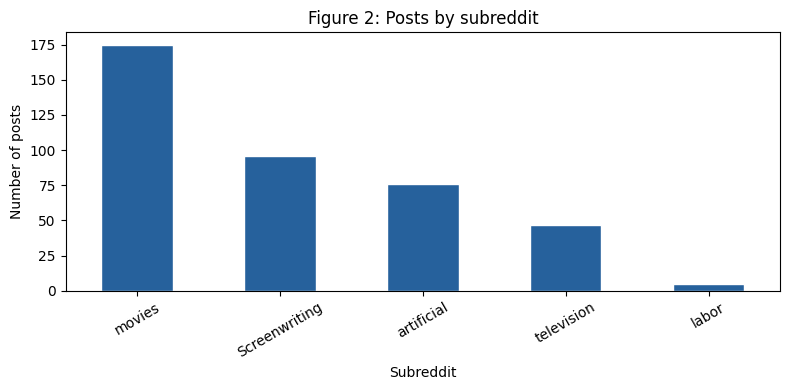

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

df["subreddit"].value_counts().plot(
    kind="bar",
    ax=ax,
    color="#26619C",
    edgecolor="white"
)

ax.set_title("Figure 2: Posts by subreddit", fontsize=12)
ax.set_xlabel("Subreddit")
ax.set_ylabel("Number of posts")

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig2_posts_by_subreddit.png", dpi=150)
plt.show()

The corpus covers a range of perspectives: general film audiences in `r/movies` (175 posts), professional writers in `r/Screenwriting` (96 posts), technology-oriented users in r/artificial (76 posts), and television communities in `r/television` (47 posts). This diversity supports cross-community comparisons between professional, entertainment, and technology perspectives. `r/labor` contributes only 5 posts and is therefore excluded from community-level comparisons. Where included, results should be interpreted with caution given the limited sample size.

Aggregating the submissions into our three macro-perspectives offers a macro-level validation of the project's longitudinal design. This categorical breakdown establishes the statistical baseline for the structural and behavioral comparisons executed in subsequent sections.

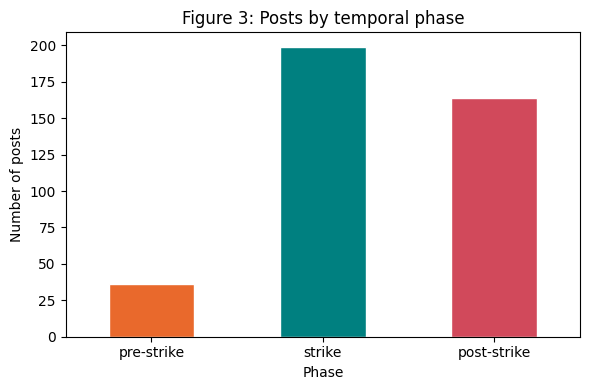

In [ ]:
phase_order = ["pre-strike", "strike", "post-strike"]
phase_counts = df["phase"].value_counts().reindex(phase_order)

fig, ax = plt.subplots(figsize=(6, 4))

phase_counts.plot(
    kind="bar",
    ax=ax,
    color=[PRE_COLOR, STRIKE_COLOR, POST_COLOR],
    edgecolor="white"
)

ax.set_title("Figure 3: Posts by temporal phase", fontsize=12)
ax.set_xlabel("Phase")
ax.set_ylabel("Number of posts")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig3_posts_by_phase.png", dpi=150)
plt.show()

The strike phase accounts for the majority of posts (199), consistent with the peak in discussion volume observed in the timeline. The post-strike phase remains well-represented (164 posts), indicating that AI-related concerns persisted beyond the formal resolution of the dispute. The pre-strike phase is smaller (36 posts), covering only two months (March–April) compared to four months each for the strike and post-strike phases. This is acknowledged as a limitation but does not substantially affect the strike and post-strike comparisons that are central to the analysis.

To preserve analytical transparency, this raw, deduplicated submissions corpus is serialized and frozen. This dataset serves as the immutable baseline input for the subsequent cleaning, filtering, and text-preprocessing pipeline.

In [ ]:
if RUN_COLLECTION:
    df.to_csv(POSTS_PATH, index=False)
    print(f"Dataset saved to: {POSTS_PATH}")

With the seed submissions secured, the analytical focus shifts toward mapping the underlying social interactions. We query the comment thread associated with each post; these metadata elements constitute the essential units for network construction, where the `parent_id` field mathematically defines the directed edges of the user interaction graph.

In [ ]:
COMMENT_URL = "https://api.pullpush.io/reddit/search/comment/"

def fetch_comments_for_post(post_id, timeout=30):
    params = {
        "link_id": post_id,
        "size": 500,
    }
    try:
        response = requests.get(COMMENT_URL, params=params, timeout=timeout)
        if response.status_code != 200:
            print(f"  [WARN] HTTP {response.status_code} for post {post_id}")
            return []
        return response.json().get("data", [])
    except requests.exceptions.Timeout:
        print(f"  [WARN] Timeout for post {post_id}")
        return []
    except Exception as e:
        print(f"  [ERROR] {e} for post {post_id}")
        return []

if RUN_COLLECTION:
    print(f"Collecting comments for {len(df)} posts...")
    print("This may take several minutes.\n")
    all_comments = []

    for i, row in df.iterrows():
        if i % 20 == 0:
            print(f"  Progress: {i}/{len(df)} posts processed...")

        comments = fetch_comments_for_post(row["id"])

        for c in comments:
            all_comments.append({
                "comment_id":  c.get("id"),
                "post_id":     row["id"],
                "subreddit":   row["subreddit"],
                "phase":       row["phase"],
                "author":      c.get("author"),
                "body":        c.get("body", ""),
                "score":       c.get("score"),
                "created_utc": datetime.fromtimestamp(c.get("created_utc"))
                               if c.get("created_utc") else None,
                "parent_id":   c.get("parent_id"),
                "is_root":     str(c.get("parent_id", "")).startswith("t3_"),
            })

        time.sleep(0.5)

    if len(all_comments) == 0:
        print("[WARN] Collection returned 0 comments. CSV not overwritten.")
        print("Loading existing dataset from Drive...")
        df_comments = pd.read_csv(COMMENTS_PATH, parse_dates=["created_utc"])
        print(f"Rows loaded: {len(df_comments)}")
    else:
        df_comments = pd.DataFrame(all_comments)
        df_comments = df_comments.drop_duplicates(
            subset="comment_id"
        ).reset_index(drop=True)
        df_comments.to_csv(COMMENTS_PATH, index=False)
        print(f"Saved {len(df_comments)} unique comments to {COMMENTS_PATH}")

else:
    print("RUN_COLLECTION = False → loading frozen comments from Drive...")
    df_comments = pd.read_csv(COMMENTS_PATH, parse_dates=["created_utc"])
    print(f"Rows loaded: {len(df_comments)}")

print(f"\nTotal unique comments: {len(df_comments)}")
print(f"Posts with at least 1 comment: {df_comments['post_id'].nunique()}")
print("\nComments per phase:")
print(df_comments["phase"].value_counts().to_string())
print("\nComments per subreddit:")
print(df_comments["subreddit"].value_counts().to_string())

RUN_COLLECTION = False → loading frozen comments from Drive...
Rows loaded: 11048

Total unique comments: 11048
Posts with at least 1 comment: 317

Comments per phase:
phase
post-strike    6799
strike         3501
pre-strike      748

Comments per subreddit:
subreddit
movies           6428
Screenwriting    2132
television       1373
artificial       1115


**Technical Note:** During comment collection, a small number of requests returned HTTP 429 errors (*Too Many Requests*), indicating that the PullPush server temporarily rate-limited the client after too many rapid requests. Affected posts received no comments in this run. The number of posts affected is minimal and does not materially alter the comment dataset or the network structure derived from it.

## **2. Preprocessing**

Before conducting network and content analysis, the collected Reddit corpus is cleaned and standardized. Several preprocessing steps are required to improve the quality and interpretability of the dataset:
* Removal of irrelevant submissions unrelated to the intersection between AI and the Hollywood Strike
* Removal of deleted, removed, and low-information content
* Filtering of problematic or automated accounts (like AutoModerator)
* Normalization of textual content through lowercasing and punctuation removal
* Tokenization and lemmatization
* Removal of English stopwords and custom domain-specific stopwords
* Filtering of very short texts with limited semantic content

In [ ]:
# Load raw dataset
df = pd.read_csv(DRIVE_PATH + 'submissions_raw.csv', parse_dates=['date'])

print(f"Raw dataset loaded: {len(df)} posts")
df.head(3)

Raw dataset loaded: 399 posts


,id,subreddit,query_key,query,title,text,author,score,upvote_ratio,num_comments,permalink,url,date,phase,full_text,month
0,11g0e3n,artificial,q06_replacement_1,AI actors,Actors as Orcs | Created with AI,[deleted],[deleted],0,0.5,0,/r/artificial/comments/11g0e3n/actors_as_orcs_...,NaN,2023-03-02 11:24:21,pre-strike,Actors as Orcs | Created with AI,2023-03
1,11g1iex,artificial,q06_replacement_1,AI actors,The editologic of deepfake Joe Biden,# The editologic of deepfake Joe Biden\n\n**EV...,walt74,2,0.6,0,/r/artificial/comments/11g1iex/the_editologic_...,https://www.reddit.com/r/artificial/comments/1...,2023-03-02 12:26:12,pre-strike,The editologic of deepfake Joe Biden # The edi...,2023-03
2,11p8bk4,labor,q06_replacement_1,AI actors,End Labor Exploitation in The Acting Industry,**It’s A Big Club And You Ain't in It: How Pay...,HeightThese1554,1,1.0,0,/r/labor/comments/11p8bk4/end_labor_exploitati...,https://www.reddit.com/r/labor/comments/11p8bk...,2023-03-12 07:19:43,pre-strike,End Labor Exploitation in The Acting Industry ...,2023-03


Broad historical search queries inevitably retrieve off-topic content, such as promotional trailers or franchise discussion threads on `r/movies` and `r/television`. To ensure that only relevant posts are retained, a keyword filter is applied to post titles, removing submissions that do not directly relate to the intersection between AI and the Hollywood Strike.

In [ ]:
RELEVANCE_KEYWORDS = [
    # Labor dispute
    "strike", "wga", "sag", "sag-aftra", "union", "writers guild",
    "picket", "labor", "contract", "negotiation", "walkout",
    # AI technology in Hollywood context
    "ai", "artificial intelligence", "generative", "chatgpt",
    "machine learning", "automation", "algorithm",
    # Specific contract issues
    "digital likeness", "synthetic", "deepfake", "likeness",
    "residuals", "streaming", "consent",
    # Key organizations and people
    "netflix", "disney", "amazon", "studios", "hollywood",
    "screenwriter", "showrunner", "actor", "writer",
]

def is_relevant(title):
    if not isinstance(title, str):
        return False
    title_lower = title.lower()
    return any(kw in title_lower for kw in RELEVANCE_KEYWORDS)

n_before = len(df)
df = df[df['title'].apply(is_relevant)].reset_index(drop=True)
n_after = len(df)

print(f"Posts before relevance filtering: {n_before}")
print(f"Posts after relevance filtering:  {n_after}")
print(f"Posts removed:                    {n_before - n_after}")

Posts before relevance filtering: 399
Posts after relevance filtering:  296
Posts removed:                    103


In [ ]:
# Manual inspection of borderline cases
print("Sample of RETAINED posts: verify relevance:")
print(df[['subreddit', 'title']].sample(min(20, len(df))).to_string(index=False))

Sample of RETAINED posts: verify relevance:
    subreddit                                                                                                                                                                                                                                                                                                           title
   television                                                                                                               SAG-AFTRA And WGA Fears About AI Are Warranted After 15 Years Of Streaming Chaos, Says Director Christopher Nolan: Companies “Don’t Want To Take Responsibility For Whatever That Algorithm Does”
   television                                                                                                                                                                                                                                              As Actors Strike for AI Protections, Netflix Lists $900,000 AI Job
Sc

Posts whose body text contains only deletion markers (`[deleted]`, `[removed]`) are cleaned by removing those markers. Where the body is empty after cleaning, the post title is used as the text input, since Reddit submissions often carry most of their content in the title alone.

In [ ]:
REDDIT_REMOVED_MARKERS = ["[deleted]", "[removed]", "[ removed ]", "[ deleted ]"]

for marker in REDDIT_REMOVED_MARKERS:
    df['text'] = df['text'].replace(marker, "")

# Rebuild full_text: title + body (if available and non-empty)
df['full_text'] = df.apply(
    lambda row: row['title'] + " " + str(row['text'])
    if pd.notna(row['text']) and str(row['text']).strip() != ""
    else row['title'],
    axis=1
)

print(f"Posts after deleted/removed handling: {len(df)}")

Posts after deleted/removed handling: 296


Automated accounts such as AutoModerator and other bots are removed from the dataset. Their activity does not reflect genuine user discussion and would otherwise inflate interaction counts in the network analysis.

In [ ]:
# Known automated accounts
EXCLUDED_AUTHORS = [
    "AutoModerator",
    "[deleted]",
    "reddit",
    "BotDefense",
    "RepostSleuthBot",
]

# Also exclude accounts whose username ends in 'Bot' or 'bot'
def is_valid_author(author):
    if not isinstance(author, str):
        return False
    if author in EXCLUDED_AUTHORS:
        return False
    if author.lower().endswith('bot'):
        return False
    return True

n_before = len(df)
df = df[df['author'].apply(is_valid_author)].reset_index(drop=True)

print(f"Posts before author filtering: {n_before}")
print(f"Posts after author filtering:  {len(df)}")
print(f"Posts removed:                 {n_before - len(df)}")

Posts before author filtering: 296
Posts after author filtering:  276
Posts removed:                 20


The sentiment and NER models used in this project are trained on English text. Non-English posts are identified using the `langdetect` library and removed to ensure that downstream NLP components produce reliable results.

In [ ]:
def detect_language(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

df['language'] = df['full_text'].apply(detect_language)

print("Language distribution:")
print(df['language'].value_counts().head(10).to_string())

Language distribution:
language
en    273
de      2
tl      1


In [ ]:
# Retain only English posts.
n_before = len(df)
df = df[df['language'] == 'en'].reset_index(drop=True)

print(f"Posts before language filtering: {n_before}")
print(f"Posts after language filtering:  {len(df)}")
print(f"Posts removed:                   {n_before - len(df)}")

Posts before language filtering: 276
Posts after language filtering:  273
Posts removed:                   3


Raw Reddit text contains noise that must be removed before NLP processing: URLs, punctuation, subreddit tags, and excessive whitespace. All text is also lowercased to ensure consistent tokenization.

In [ ]:
def normalize_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs (http/https and www)
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove Reddit-specific markup (subreddit and user mentions)
    text = re.sub(r'r/\w+|u/\w+', '', text)

    # Remove punctuation and special characters, keep alphanumeric and spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text_normalized'] = df['full_text'].apply(normalize_text)

# Quick sanity check
print("Example — original vs normalized:")
for i in range(3):
    print(f"\nOriginal:   {df['full_text'].iloc[i][:120]}")
    print(f"Normalized: {df['text_normalized'].iloc[i][:120]}")

Example — original vs normalized:

Original:   The editologic of deepfake Joe Biden # The editologic of deepfake Joe Biden

**EVERYTHING’S TRUE IN LALALAND**

[Ryan Br
Normalized: the editologic of deepfake joe biden the editologic of deepfake joe biden everything s true in lalaland ryan broderick w

Original:   End Labor Exploitation in The Acting Industry **It’s A Big Club And You Ain't in It: How Pay-to-Play Casting Workshops R
Normalized: end labor exploitation in the acting industry it s a big club and you ain t in it how pay to play casting workshops rob 

Original:   When AI gets to where it can generate movies, what existing or cancelled movie will you try generate? AI is advancing so
Normalized: when ai gets to where it can generate movies what existing or cancelled movie will you try generate ai is advancing so f


Each post is tokenized, filtered for stopwords, and lemmatized. Lemmatization is preferred over stemming because it reduces words to their correct base form (for instance *writing* → *write*) while preserving readability.

Standard English stopwords are extended with a custom list of domain-specific terms. High-frequency collection keywords such as *ai*, *hollywood*, and *wga* are excluded because they appear in nearly every post and would otherwise dominate frequency profiles without contributing to frame differentiation.

In [ ]:
# Custom stopword list
CUSTOM_STOPWORDS = {
    # Collection query keywords — present in almost every post by construction
    "ai", "hollywood", "wga", "sag", "sagaftra", "strike",
    "writer", "writers", "actor", "actors", "artificial", "intelligence",
    # Platform artifacts — Reddit-specific noise
    "reddit", "post", "comment", "thread", "edit", "update",
    "subreddit", "mod", "mods", "upvote", "downvote",
    # Generic high-frequency terms with low discriminative value
    "think", "know", "want", "people", "thing", "good", "make",
    "like", "get", "go", "say", "just", "really", "would",
    "also", "even", "still", "well", "way", "year", "time",
    "true", "false", "new", "use", "need", "work", "look",
    # HTML artifacts and residual noise
    "don", "cent", "come", "feel", "amp", "got", "lot", "one", "two",
    # Additional noise identified via word cloud inspection
    "takeaway", "detail", "let", "right", "real", "big", "long",
    "different", "able", "try", "point", "show", "help", "ask",
    "find", "mean", "set", "read", "give", "take", "start", "end",
    "go", "thing", "detail", "see", "talk"
    }

# Add custom stopwords to spaCy's built-in English stopword list
for word in CUSTOM_STOPWORDS:
    nlp.vocab[word].is_stop = True

print(f"Custom stopwords added: {len(CUSTOM_STOPWORDS)}")
print("Custom stopwords successfully added to spaCy vocabulary.")

Custom stopwords added: 84
Custom stopwords successfully added to spaCy vocabulary.


In [ ]:
def tokenize_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.text) >= 3
    ]
    return tokens

# Apply to the full corpus
print("Tokenizing and lemmatizing corpus... (this may take a few minutes)")
df['tokens'] = df['text_normalized'].apply(tokenize_and_lemmatize)
df['tokens_str'] = df['tokens'].apply(lambda t: ' '.join(t))

print(f"\nDone. Example tokens:")
for i in range(3):
    print(f"  {df['tokens'].iloc[i][:15]}")

Tokenizing and lemmatizing corpus... (this may take a few minutes)

Done. Example tokens:
  ['editologic', 'deepfake', 'joe', 'biden', 'editologic', 'deepfake', 'joe', 'biden', 'lalaland', 'ryan', 'broderick', 'write', 'garbage', 'day', 'context']
  ['labor', 'exploitation', 'act', 'industry', 'club', 'ain', 'pay', 'play', 'casting', 'workshop', 'rob', 'society', 'theater', 'art', 'imperil']
  ['get', 'generate', 'movie', 'exist', 'cancel', 'movie', 'generate', 'advance', 'fast', 'conceivable', 'soon', 'capable', 'produce', 'feature', 'length']


Posts with fewer than five tokens after preprocessing are removed. These very short texts carry too little content to support reliable frame or sentiment analysis.

In [ ]:
MIN_TOKENS = 5

df['token_count'] = df['tokens'].apply(len)

n_before = len(df)
df = df[df['token_count'] >= MIN_TOKENS].reset_index(drop=True)

print(f"Posts before token filter: {n_before}")
print(f"Posts after token filter:  {len(df)}")
print(f"Posts removed:             {n_before - len(df)}")
print()
print("Token count distribution:")
print(df['token_count'].describe().round(1).to_string())

Posts before token filter: 273
Posts after token filter:  255
Posts removed:             18

Token count distribution:
count     255.0
mean      110.3
std       194.1
min         5.0
25%        14.0
50%        35.0
75%       130.0
max      1940.0


Finally, these are the statistics about the preprocessed dataset.

In [ ]:
print("=" * 55)
print("CLEAN DATASET SUMMARY")
print("=" * 55)
print(f"Total posts:       {len(df)}")
print(f"Unique authors:    {df['author'].nunique()}")
print(f"Subreddits:        {df['subreddit'].nunique()}")
print()
print("Posts per phase:")
print(df['phase'].value_counts().to_string())
print()
print("Posts per subreddit:")
print(df['subreddit'].value_counts().to_string())
print()
print("Average token count per subreddit:")
print(df.groupby('subreddit')['token_count'].mean().round(1).to_string())

CLEAN DATASET SUMMARY
Total posts:       255
Unique authors:    179
Subreddits:        5

Posts per phase:
phase
strike         141
post-strike     87
pre-strike      27

Posts per subreddit:
subreddit
movies           79
Screenwriting    70
artificial       65
television       37
labor             4

Average token count per subreddit:
subreddit
Screenwriting    158.6
artificial       169.6
labor             90.0
movies            52.2
television        40.7


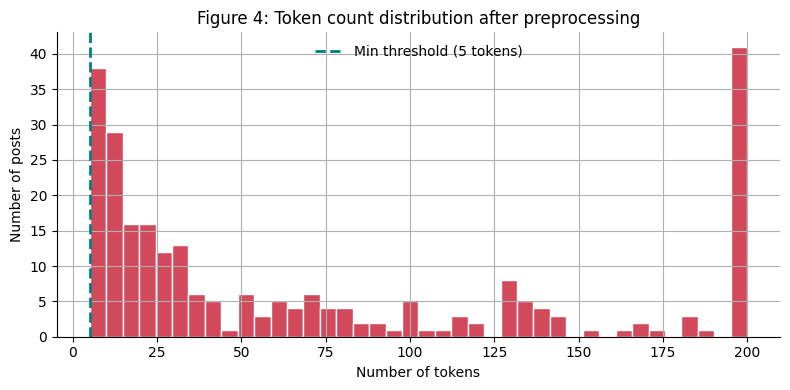

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

df['token_count'].clip(upper=200).hist(bins=40, ax=ax, color=POST_COLOR, edgecolor='white')

ax.axvline(
    x=MIN_TOKENS,
    color=STRIKE_COLOR,
    linestyle='--',
    linewidth=2,
    label=f'Min threshold ({MIN_TOKENS} tokens)'
)

ax.set_title(
    'Figure 4: Token count distribution after preprocessing',
    fontsize=12,
    color='#000000'
)

ax.set_xlabel('Number of tokens', color='#000000')

ax.set_ylabel('Number of posts', color='#000000')

ax.tick_params(colors='#000000')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    DRIVE_PATH_IMAGES + "fig4_token_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

The token count distribution shows the expected right-skewed pattern typical of social media corpora, with many short posts and a smaller number of longer ones. The filtering threshold removes the least informative texts while preserving the bulk of the corpus.

In [ ]:
# Save cleaned dataset after preprocessing
output_path = DRIVE_PATH + "submissions_clean.csv"
df.to_csv(output_path, index=False)

print(f"Clean dataset saved to: {output_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Clean dataset saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/submissions_clean.csv
Rows: 255
Columns: ['id', 'subreddit', 'query_key', 'query', 'title', 'text', 'author', 'score', 'upvote_ratio', 'num_comments', 'permalink', 'url', 'date', 'phase', 'full_text', 'month', 'language', 'text_normalized', 'tokens', 'tokens_str', 'token_count']


The same preprocessing pipeline applied to submissions is now applied to the comments corpus. Identical normalization, stopword filtering, and lemmatization steps ensure that comment-level text is processed consistently with the submissions, allowing direct comparison across the two datasets.


In [ ]:
# Load raw comments
df_comments = pd.read_csv(DRIVE_PATH + "comments_raw.csv", parse_dates=["created_utc"])
print(f"Raw comments loaded: {len(df_comments)}")

# Step 1: Remove deleted/removed/bot comments
EXCLUDED_AUTHORS = [
    "AutoModerator", "[deleted]", "reddit",
    "BotDefense", "RepostSleuthBot"
]

df_comments = df_comments[
    df_comments["author"].apply(is_valid_author)
].reset_index(drop=True)

# Remove deleted/removed body text
for marker in REDDIT_REMOVED_MARKERS:
    df_comments["body"] = df_comments["body"].replace(marker, "")

df_comments = df_comments[
    df_comments["body"].notna() &
    (df_comments["body"].str.strip() != "")
].reset_index(drop=True)

print(f"After author/content filtering: {len(df_comments)}")

# Step 2: Language filtering (English only)
df_comments["language"] = df_comments["body"].apply(detect_language)
df_comments = df_comments[
    df_comments["language"] == "en"
].reset_index(drop=True)
print(f"After language filtering: {len(df_comments)}")

# Step 3: Text normalization
df_comments["text_normalized"] = df_comments["body"].apply(normalize_text)

# Step 4: Tokenization and lemmatization
print("Tokenizing and lemmatizing comments... (this may take a few minutes)")
df_comments["tokens"] = df_comments["text_normalized"].apply(tokenize_and_lemmatize)
df_comments["tokens_str"] = df_comments["tokens"].apply(lambda t: " ".join(t))

# Step 5: Minimum token filter
df_comments["token_count"] = df_comments["tokens"].apply(len)
n_before = len(df_comments)
df_comments = df_comments[
    df_comments["token_count"] >= MIN_TOKENS
].reset_index(drop=True)
print(f"After token filter: {len(df_comments)} (removed {n_before - len(df_comments)})")

print("\n── CLEAN COMMENTS SUMMARY ──")
print(f"Total comments:     {len(df_comments)}")
print(f"Unique authors:     {df_comments['author'].nunique()}")
print(f"Unique posts:       {df_comments['post_id'].nunique()}")
print("\nComments per phase:")
print(df_comments["phase"].value_counts().to_string())

Raw comments loaded: 11048
After author/content filtering: 10605
After language filtering: 10167
Tokenizing and lemmatizing comments... (this may take a few minutes)
After token filter: 7988 (removed 2179)

── CLEAN COMMENTS SUMMARY ──
Total comments:     7988
Unique authors:     4709
Unique posts:       285

Comments per phase:
phase
post-strike    4926
strike         2524
pre-strike      538


The clean comments dataset contains 7,988 comments from 4,709 unique authors. The phase distribution mirrors the submission-level trend: engagement peaks during the strike (2,524 comments) and remains high in the post-strike period (4,926 comments). This dataset forms the basis for the reply interaction network constructed in Section 5.

In [ ]:
# Save clean comments
clean_comments_path = DRIVE_PATH + "comments_clean.csv"
df_comments.to_csv(clean_comments_path, index=False)
print(f"Clean comments saved to: {clean_comments_path}")

Clean comments saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/comments_clean.csv


## **3. Exploratory Content Analysis**
This section explores the cleaned Reddit submissions corpus before applying formal frame detection. The goal is to identify the most frequent lexical patterns, compare vocabulary across subreddits and temporal phases, and verify whether the expected analytical frames emerge from the data.

In [ ]:
# Load cleaned dataset
df = pd.read_csv(DRIVE_PATH + "submissions_clean.csv", parse_dates=["date"])

print(f"Clean dataset loaded: {len(df)} posts")
df.head(3)

Clean dataset loaded: 255 posts


,id,subreddit,query_key,query,title,text,author,score,upvote_ratio,num_comments,...,url,date,phase,full_text,month,language,text_normalized,tokens,tokens_str,token_count
0,11g1iex,artificial,q06_replacement_1,AI actors,The editologic of deepfake Joe Biden,# The editologic of deepfake Joe Biden\n\n**EV...,walt74,2,0.60,0,...,https://www.reddit.com/r/artificial/comments/1...,2023-03-02 12:26:12,pre-strike,The editologic of deepfake Joe Biden # The edi...,2023-03,en,the editologic of deepfake joe biden the edito...,"['editologic', 'deepfake', 'joe', 'biden', 'ed...",editologic deepfake joe biden editologic deepf...,434
1,11p8bk4,labor,q06_replacement_1,AI actors,End Labor Exploitation in The Acting Industry,**It’s A Big Club And You Ain't in It: How Pay...,HeightThese1554,1,1.00,0,...,https://www.reddit.com/r/labor/comments/11p8bk...,2023-03-12 07:19:43,pre-strike,End Labor Exploitation in The Acting Industry ...,2023-03,en,end labor exploitation in the acting industry ...,"['labor', 'exploitation', 'act', 'industry', '...",labor exploitation act industry club ain pay p...,337
2,11vjv2r,movies,q06_replacement_1,AI actors,"When AI gets to where it can generate movies, ...",AI is advancing so fast it is conceivable that...,couchdollarz,0,0.28,16,...,https://www.reddit.com/r/movies/comments/11vjv...,2023-03-19 12:16:44,pre-strike,"When AI gets to where it can generate movies, ...",2023-03,en,when ai gets to where it can generate movies w...,"['get', 'generate', 'movie', 'exist', 'cancel'...",get generate movie exist cancel movie generate...,30


The cleaned dataset contains 255 Reddit submissions after relevance filtering, language filtering, and NLP preprocessing.

The preview confirms that metadata, temporal information, subreddit labels, and normalized textual fields were successfully preserved for subsequent analyses.

We first inspect the most frequent lemmatized tokens in the full corpus. This helps verify whether the preprocessing step successfully removed generic collection terms and whether meaningful concepts related to AI, labor, creativity, and corporate power emerge.

In [ ]:
all_tokens = [token for tokens in df["tokens_str"].dropna() for token in tokens.split()]
word_freq = Counter(all_tokens)

word_freq_df = pd.DataFrame(
    word_freq.most_common(30),
    columns=["word", "frequency"]
)

word_freq_df.head(30)

,word,frequency
0,write,208
1,human,160
2,studio,159
3,movie,150
4,generate,136
5,create,134
6,model,133
7,script,126
8,content,121
9,go,117


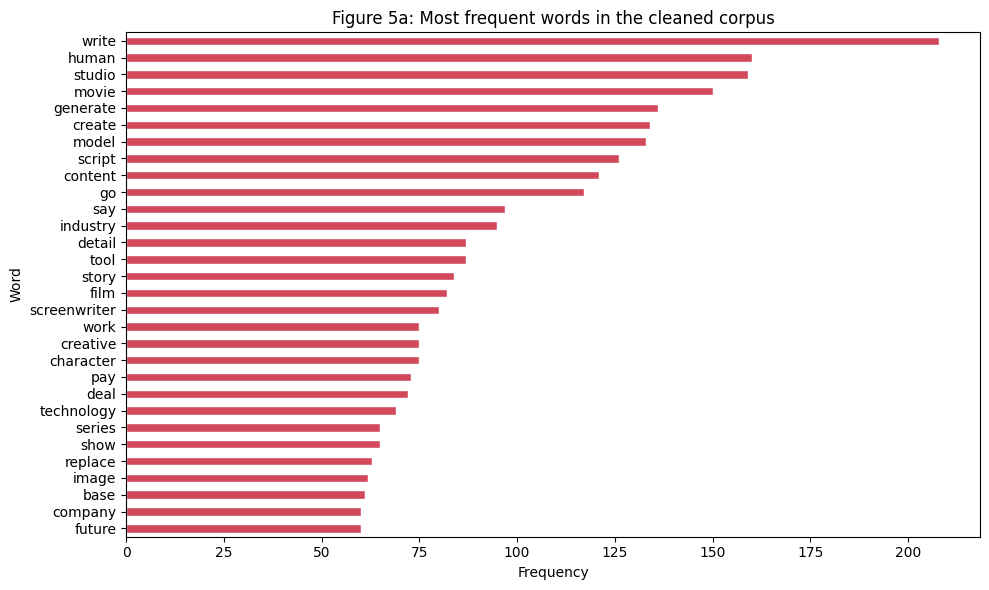

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

word_freq_df.sort_values("frequency").plot(
    kind="barh",
    x="word",
    y="frequency",
    ax=ax,
    color=POST_COLOR,
    edgecolor="white",
    legend=False
)

ax.set_title("Figure 5a: Most frequent words in the cleaned corpus", fontsize=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("Word")

plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig5a_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

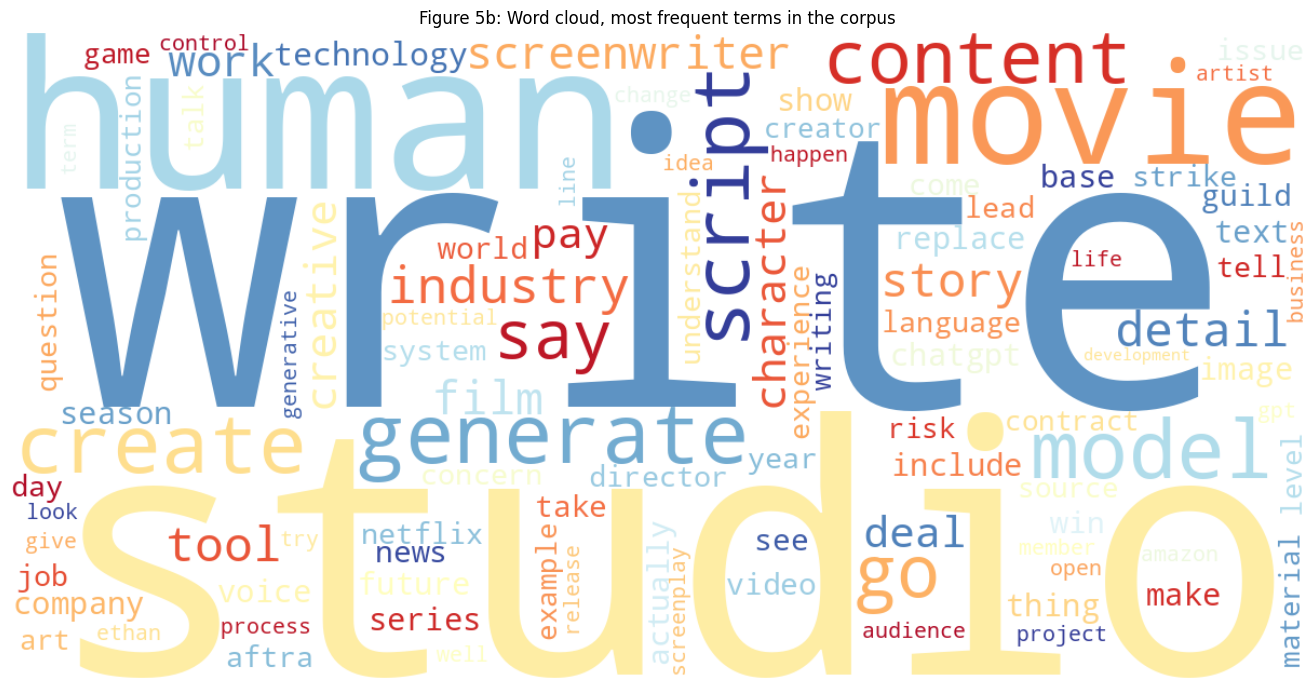

In [ ]:
text_for_cloud = " ".join(all_tokens)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="RdYlBu",
    max_words=100,
    collocations=False
).generate(text_for_cloud)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Figure 5b: Word cloud, most frequent terms in the corpus", fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig5b_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

The most frequent terms provide an initial overview of the thematic structure of the corpus.

The dominance of words associated with writing, screen production and human creativity confirms that the Hollywood Strike was primarily discussed as a labor and creative-industry issue rather than a purely technological debate.

Simultaneously, AI-related terms such as model, generate, and technology appear among the most frequent words, highlighting how artificial intelligence became integrated into broader concerns about employment, authorship, and industry change.


Single words are useful, but many frames are expressed through combinations of words, such as “digital likeness”, “job replacement”, or “creative work”. Therefore, we extract frequent bigrams to better capture recurring expressions in the discourse.

In [ ]:
nltk.download("punkt")

all_bigrams = []

for tokens in df["tokens_str"].dropna():
    token_list = tokens.split()
    all_bigrams.extend(list(ngrams(token_list, 2)))

bigram_freq = Counter(all_bigrams)

bigram_freq_df = pd.DataFrame(
    [(f"{w1} {w2}", freq) for (w1, w2), freq in bigram_freq.most_common(30)],
    columns=["bigram", "frequency"]
)

bigram_freq_df.head(30)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,bigram,frequency
0,generate content,19
1,picket line,15
2,2023 skim,14
3,skim trade,14
4,language model,14
5,open source,12
6,speech speech,12
7,amazon titan,12
8,entertainment industry,11
9,text image,11


Several expressions directly connect AI technologies with the Hollywood labor dispute, including language model, generate content, write script, copyright protection, and entertainment industry. These combinations indicate that users frequently debated the impact of generative AI on creative production and intellectual property.

Some recurring bigrams, such as weekly megathread, test ethan, villain ethan, and wrap monday, appear to originate from subreddit-specific discussion formats or recurring community references. These artifacts are retained for transparency but should not be interpreted as substantive thematic findings.

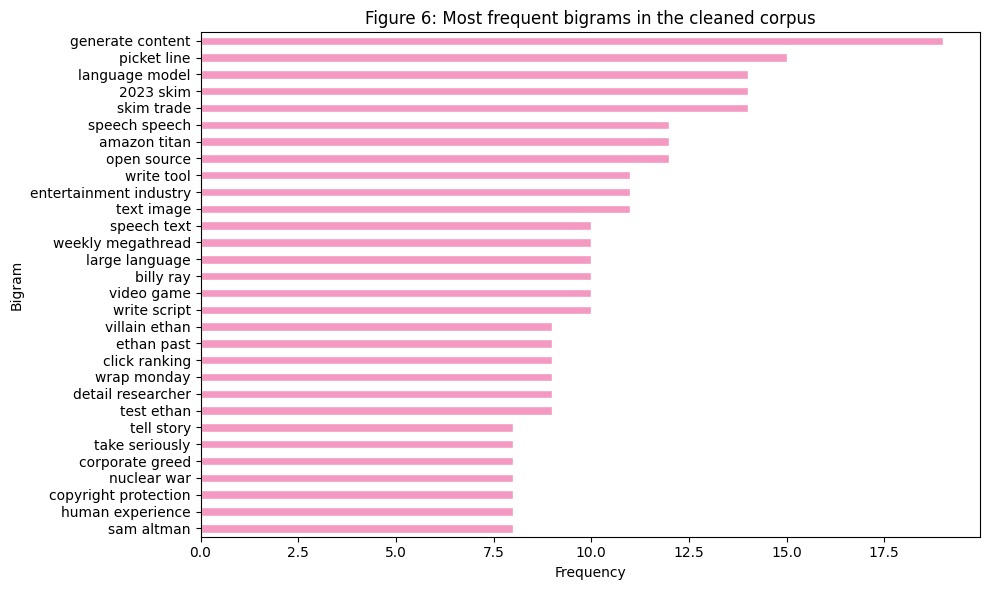

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bigram_freq_df.sort_values("frequency").plot(
    kind="barh",
    x="bigram",
    y="frequency",
    ax=ax,
    color=ACCENT_COLOR,
    edgecolor="white",
    legend=False
)

ax.set_title("Figure 6: Most frequent bigrams in the cleaned corpus", fontsize=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("Bigram")

plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig6_top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()

Now the most frequent words across subreddits are compared. Since each subreddit represents a different online community, lexical differences can provide early evidence that AI was framed differently by screenwriters, general movie audiences, technology-oriented users, and television communities.

In [ ]:
def top_words_by_group(data, group_col, text_col="tokens_str", top_n=15):
    rows = []

    for group, group_df in data.groupby(group_col):
        tokens = [
            token
            for text in group_df[text_col].dropna()
            for token in text.split()
        ]
        freq = Counter(tokens)

        for word, count in freq.most_common(top_n):
            rows.append({
                group_col: group,
                "word": word,
                "frequency": count
            })

    return pd.DataFrame(rows)

top_words_subreddit = top_words_by_group(df, "subreddit", top_n=10)
top_words_subreddit.head(20)

,subreddit,word,frequency
0,Screenwriting,write,101
1,Screenwriting,studio,89
2,Screenwriting,script,81
3,Screenwriting,screenwriter,77
4,Screenwriting,industry,60
5,Screenwriting,go,53
6,Screenwriting,season,51
7,Screenwriting,series,51
8,Screenwriting,human,48
9,Screenwriting,deal,47


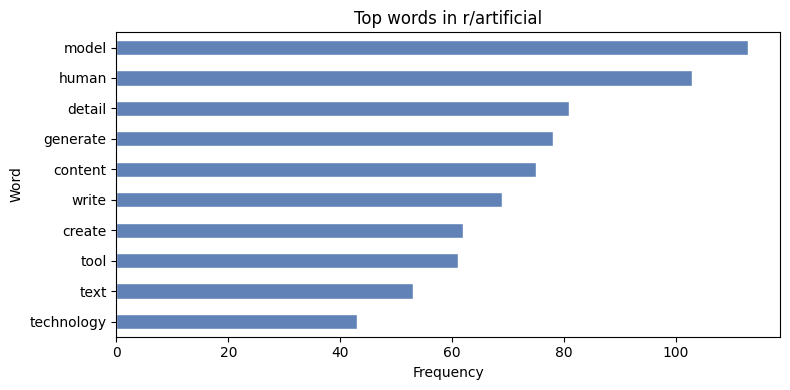

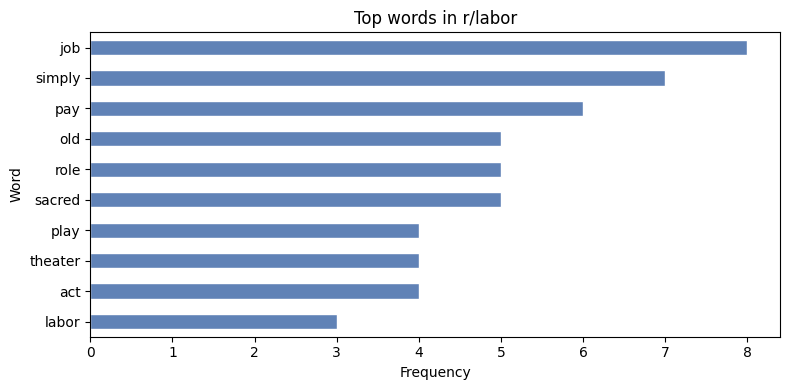

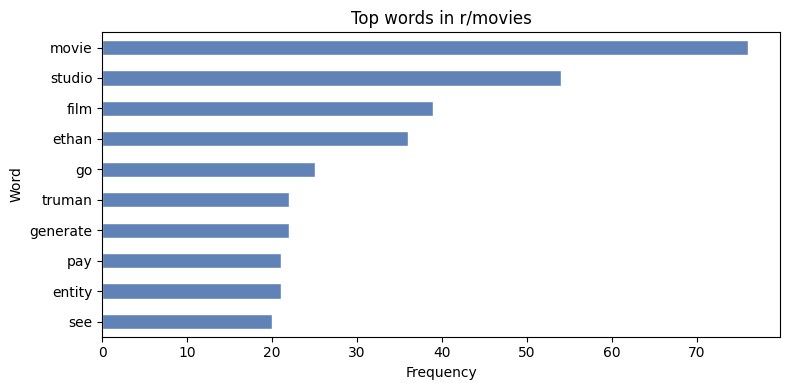

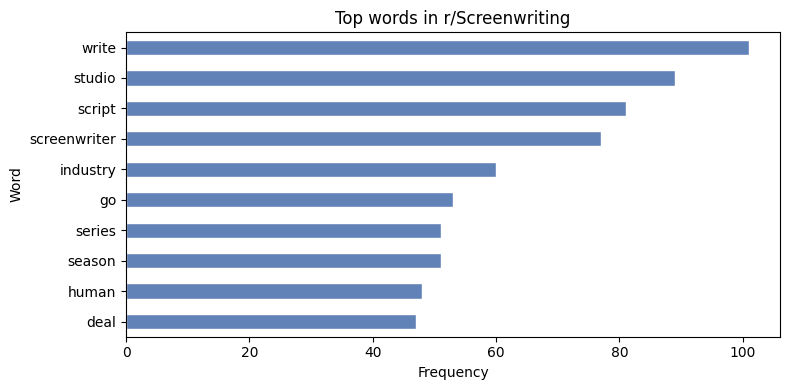

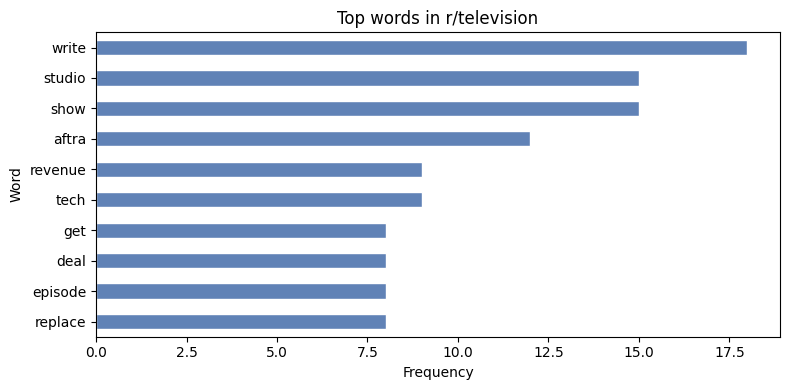

In [ ]:
for subreddit in df["subreddit"].unique():
    temp = top_words_subreddit[top_words_subreddit["subreddit"] == subreddit]

    fig, ax = plt.subplots(figsize=(8, 4))

    temp.sort_values("frequency").plot(
        kind="barh",
        x="word",
        y="frequency",
        ax=ax,
        color=NEUTRAL_COLOR,
        edgecolor="white",
        legend=False
    )

    ax.set_title(f"Top words in r/{subreddit}", fontsize=12)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")

    plt.tight_layout()
    plt.savefig(DRIVE_PATH + f"top_words_{subreddit}.png", dpi=150, bbox_inches="tight")
    plt.show()

The subreddit-level comparison reveals clear thematic differences across communities.

`r/artificial` focuses primarily on AI technologies, content generation, and technical concepts, reflecting a technology-centered perspective. `r/Screenwriting` emphasizes writing professions, scripts, studios, and creative work, consistent with the professional interests of its users.

Meanwhile, `r/movies` and `r/television` combine references to entertainment production with discussions of AI adoption and industry transformation. The labor-oriented subreddit exhibits a distinct vocabulary centered on jobs, pay, labor conditions, and workplace roles.

Now the goal is to check whether the language changes across phases and whether some concepts become more central during the strike period.

In [ ]:
top_words_phase = top_words_by_group(df, "phase", top_n=15)
top_words_phase.head(30)

,phase,word,frequency
0,post-strike,detail,67
1,post-strike,model,65
2,post-strike,write,62
3,post-strike,content,49
4,post-strike,script,49
5,post-strike,generate,48
6,post-strike,create,46
7,post-strike,series,43
8,post-strike,studio,43
9,post-strike,deal,42


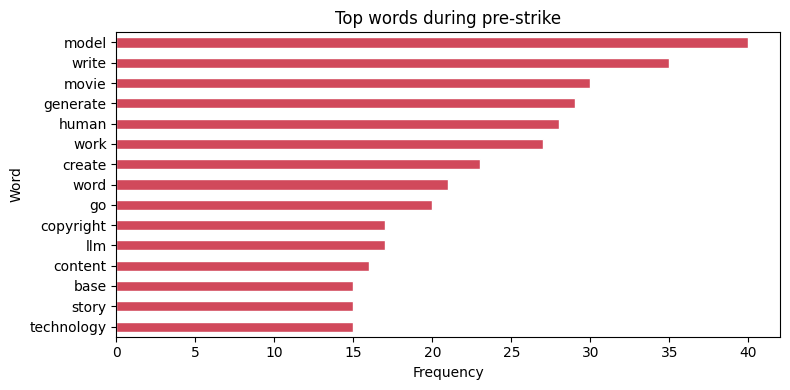

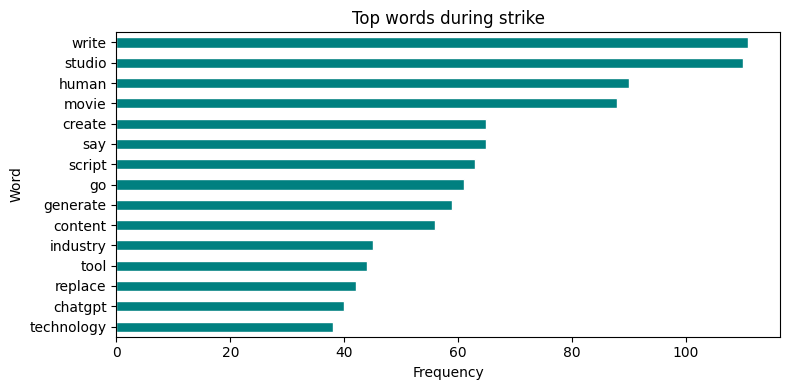

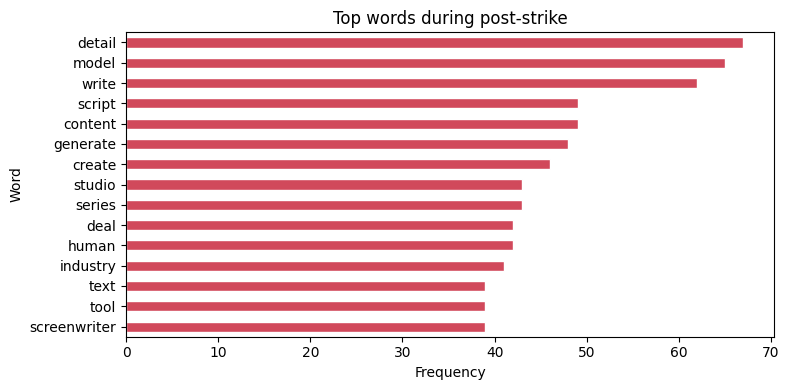

In [ ]:
for phase in ["pre-strike", "strike", "post-strike"]:
    temp = top_words_phase[top_words_phase["phase"] == phase]

    fig, ax = plt.subplots(figsize=(8, 4))

    temp.sort_values("frequency").plot(
        kind="barh",
        x="word",
        y="frequency",
        ax=ax,
        color=STRIKE_COLOR if phase == "strike" else POST_COLOR,
        edgecolor="white",
        legend=False
    )

    ax.set_title(f"Top words during {phase}", fontsize=12)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")

    plt.tight_layout()
    plt.savefig(DRIVE_PATH + f"top_words_{phase}.png", dpi=150, bbox_inches="tight")
    plt.show()

Before the strike, discussions were strongly characterized by terms such as model, generate, technology, and copyright, indicating substantial attention to AI capabilities and their potential implications for creative work. During the strike itself, most frequent words reflect a stronger focus on professional writers, labor concerns, and the relationship between AI systems and creative workers.

In the post-strike period, discussions continued to combine technological and industry-oriented themes. Terms such as model, generate, tool, content, and screenwriter suggest that attention shifted toward the long-term integration of AI technologies within creative industries and the practical consequences of the agreements reached during the dispute.

## **4. Frame Detection**

After exploring the corpus, we define a set of theory-driven frames related to the research question. Each frame represents a different way of interpreting AI during the Hollywood Strike: as a threat to jobs, a labor rights issue, a problem of authenticity and creativity, an instrument of corporate power, or an opportunity for innovation.

In [ ]:
FRAME_DICTIONARIES = {
    "replacement_anxiety": [
        "replace", "replacement", "threat", "automate", "obsolete",
        "fear", "lose", "loss", "danger", "displace", "extinct",
        "job", "unemployment", "layoff", "redundant", "eliminate"
    ],
    "workers_rights": [
        "union", "contract", "consent", "residual", "guild",
        "protection", "rights", "negotiate", "picket", "bargain", "safeguard",
        "wage", "pay", "salary", "worker", "labor", "demand"
    ],
    "authenticity_creativity": [
        "soul", "original", "creativity", "creative", "expression",
        "authentic", "authorship", "storytell", "art", "craft", "vision",
        "human", "write", "script", "story", "character"
    ],
    "corporate_power": [
        "studio", "profit", "exploit", "control", "executive",
        "greed", "corporate", "netflix", "disney", "amazon", "mogul",
        "industry", "company", "boss", "power", "money"
    ],
    "innovation_opportunity": [
        "tool", "productivity", "opportunity", "progress", "advance",
        "generate", "capable", "efficient", "assist",
        "technology", "model", "future", "potential", "improve"
    ]
}

For each post, we count how many words match each frame dictionary. The frame with the highest score is assigned as the dominant frame. Posts with no frame-related keywords are labeled as “unclassified”.

In [ ]:
def score_frames(tokens_str):
    if not isinstance(tokens_str, str):
        return {frame: 0 for frame in FRAME_DICTIONARIES}

    tokens = tokens_str.split()
    scores = {}

    for frame, keywords in FRAME_DICTIONARIES.items():
        scores[frame] = sum(1 for token in tokens if token in keywords)

    return scores

# Drop frame columns if they already exist from a previous run
existing_frame_cols = [col for col in df.columns if col in FRAME_DICTIONARIES]
if existing_frame_cols:
    df = df.drop(columns=existing_frame_cols)

# Apply frame scoring
frame_scores = df["tokens_str"].apply(score_frames)
frame_scores_df = pd.DataFrame(list(frame_scores), index=df.index)

df = pd.concat([df, frame_scores_df], axis=1)

df.head(3)

,id,subreddit,query_key,query,title,text,author,score,upvote_ratio,num_comments,...,language,text_normalized,tokens,tokens_str,token_count,replacement_anxiety,workers_rights,authenticity_creativity,corporate_power,innovation_opportunity
0,11g1iex,artificial,q06_replacement_1,AI actors,The editologic of deepfake Joe Biden,# The editologic of deepfake Joe Biden\n\n**EV...,walt74,2,0.60,0,...,en,the editologic of deepfake joe biden the edito...,"['editologic', 'deepfake', 'joe', 'biden', 'ed...",editologic deepfake joe biden editologic deepf...,434,2,3,14,2,5
1,11p8bk4,labor,q06_replacement_1,AI actors,End Labor Exploitation in The Acting Industry,**It’s A Big Club And You Ain't in It: How Pay...,HeightThese1554,1,1.00,0,...,en,end labor exploitation in the acting industry ...,"['labor', 'exploitation', 'act', 'industry', '...",labor exploitation act industry club ain pay p...,337,10,10,14,8,1
2,11vjv2r,movies,q06_replacement_1,AI actors,"When AI gets to where it can generate movies, ...",AI is advancing so fast it is conceivable that...,couchdollarz,0,0.28,16,...,en,when ai gets to where it can generate movies w...,"['get', 'generate', 'movie', 'exist', 'cancel'...",get generate movie exist cancel movie generate...,30,0,0,1,0,7


In [ ]:
def assign_dominant_frame(row):
    scores = {frame: row[frame] for frame in FRAME_DICTIONARIES}
    max_score = max(scores.values())

    if max_score == 0:
        return "unclassified"

    top_frames = [frame for frame, score in scores.items() if score == max_score]

    if len(top_frames) > 1:
        return "mixed"

    return top_frames[0]


df["dominant_frame"] = df.apply(assign_dominant_frame, axis=1)

df["dominant_frame"].value_counts()

,count
dominant_frame,
authenticity_creativity,63
corporate_power,48
innovation_opportunity,47
mixed,42
workers_rights,30
replacement_anxiety,16
unclassified,9


The frame distribution provides a first overview of how AI was discussed within the collected corpus.

The most frequent frame is `authenticity_creativity`, suggesting that many discussions focused on human authorship, artistic expression, and the role of creativity in an AI-enabled entertainment industry. `Corporate_power` and `innovation_opportunity` also appear frequently, indicating substantial attention to both institutional actors and the technological potential of AI systems.

`Workers_rights` and `replacement_anxiety` are present but less dominant, suggesting that concerns about labor protection and job displacement were important components of the debate without representing its primary focus. The presence of mixed posts further indicates that many discussions combined multiple perspectives simultaneously.

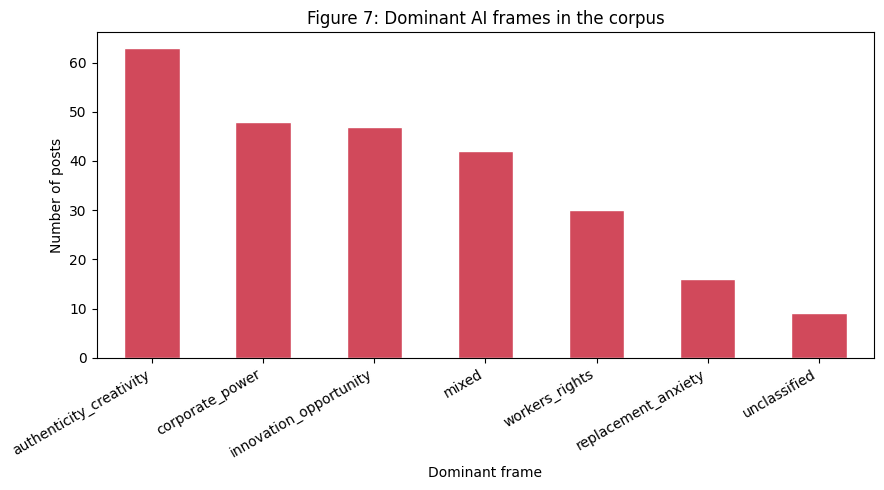

In [ ]:
frame_counts = df["dominant_frame"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

frame_counts.plot(
    kind="bar",
    ax=ax,
    color=POST_COLOR,
    edgecolor="white"
)

ax.set_title("Figure 7: Dominant AI frames in the corpus", fontsize=12)
ax.set_xlabel("Dominant frame")
ax.set_ylabel("Number of posts")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig7_frame_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The figure confirms that discussions about AI during the Hollywood Strike extended beyond simple fears of automation.

Authenticity and creativity emerge as the dominant interpretative lens, highlighting concerns about authorship, originality, and the relationship between human creators and AI-generated content. Corporate power and innovation opportunity follow closely, suggesting that Reddit users frequently debated both the influence of studios and technology companies and the potential benefits of AI adoption.

This analysis compares how different Reddit communities framed AI. It helps determine whether screenwriting communities, general entertainment audiences, and technology-oriented users emphasized different aspects of the debate

In [ ]:
frame_by_subreddit = pd.crosstab(
    df["subreddit"],
    df["dominant_frame"],
    normalize="index"
)

frame_by_subreddit

dominant_frame,authenticity_creativity,corporate_power,innovation_opportunity,mixed,replacement_anxiety,unclassified,workers_rights
subreddit,,,,,,,
Screenwriting,0.400000,0.257143,0.071429,0.114286,0.028571,0.014286,0.114286
artificial,0.246154,0.015385,0.446154,0.076923,0.123077,0.046154,0.046154
labor,0.250000,0.000000,0.000000,0.500000,0.000000,0.250000,0.000000
movies,0.151899,0.265823,0.139241,0.227848,0.050633,0.025316,0.139241
television,0.162162,0.216216,0.054054,0.243243,0.054054,0.054054,0.216216


The results suggest substantial variation between communities. Technology-oriented spaces, professional creative communities, and entertainment-focused audiences emphasize different aspects of the AI debate, reflecting their distinct interests and experiences.

Framing is not uniform across Reddit but is influenced by the social and professional context of each community.

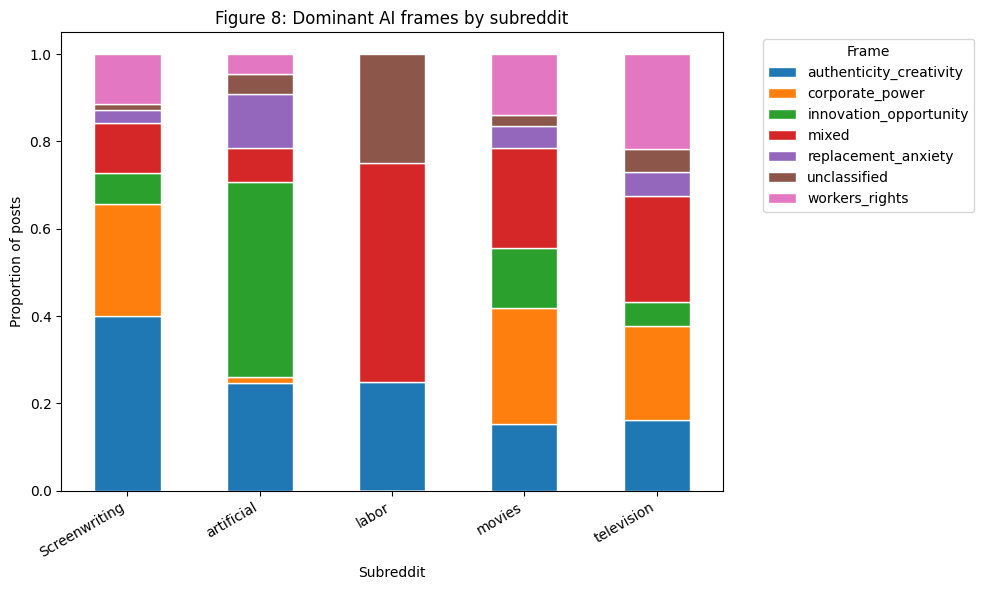

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

frame_by_subreddit.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="white"
)

ax.set_title("Figure 8: Dominant AI frames by subreddit", fontsize=12)
ax.set_xlabel("Subreddit")
ax.set_ylabel("Proportion of posts")

plt.xticks(rotation=30, ha="right")
plt.legend(title="Frame", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig8_frames_by_subreddit.png", dpi=150, bbox_inches="tight")
plt.show()

`r/artificial` shows the strongest presence of the innovation_opportunity frame, indicating a greater focus on technological progress, AI capabilities and future applications. In contrast, `r/Screenwriting` places much stronger emphasis on `authenticity_creativity`, reflecting concerns about authorship, creative identity, and the impact of AI on professional writing.

Entertainment-oriented communities such as `r/movies` and `r/television` display a more balanced distribution of frames, combining discussions about creativity, corporate influence, labor issues and technological change.

Meanwhile, the labor subreddit contains a particularly high proportion of mixed posts, suggesting that labor-oriented discussions frequently combined several concerns simultaneously rather than focusing on a single interpretative frame.

This step checks whether AI framing changed before, during, and after the strike. It allows us to test whether the strike period intensified replacement anxiety, workers’ rights discourse, or concerns about corporate power.

In [ ]:
frame_by_phase = pd.crosstab(
    df["phase"],
    df["dominant_frame"],
    normalize="index"
).reindex(["pre-strike", "strike", "post-strike"])

frame_by_phase

dominant_frame,authenticity_creativity,corporate_power,innovation_opportunity,mixed,replacement_anxiety,unclassified,workers_rights
phase,,,,,,,
pre-strike,0.333333,0.000000,0.333333,0.074074,0.074074,0.111111,0.074074
strike,0.262411,0.248227,0.113475,0.205674,0.070922,0.014184,0.085106
post-strike,0.195402,0.149425,0.252874,0.126437,0.045977,0.045977,0.183908


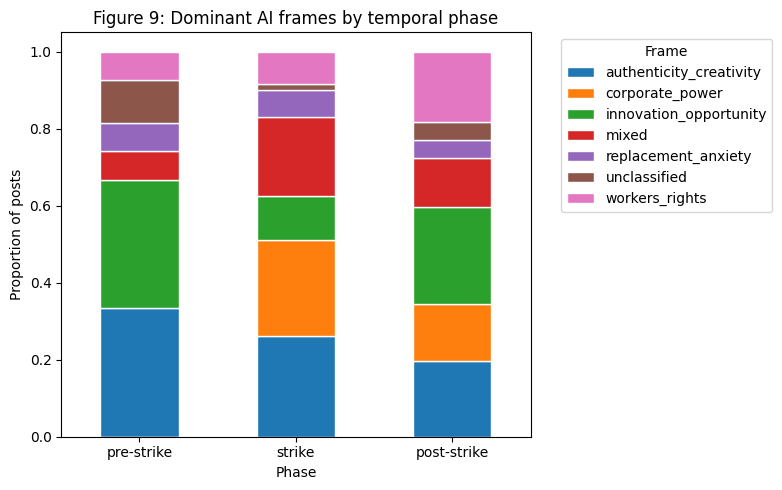

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
frame_by_phase.plot(
    kind="bar", stacked=True, ax=ax, edgecolor="white"
)
ax.set_title("Figure 9: Dominant AI frames by temporal phase", fontsize=12)
ax.set_xlabel("Phase")
ax.set_ylabel("Proportion of posts")
plt.xticks(rotation=0)
plt.legend(title="Frame", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig9_frames_by_phase.png", dpi=150, bbox_inches="tight")
plt.show()


Before the strike, discussions were largely dominated by `authenticity_creativity` and `innovation_opportunity`, indicating substantial attention to both creative concerns and the emerging capabilities of generative AI technologies. During the strike itself, `corporate_power` became considerably more prominent, reflecting increased discussion of studios, contracts, bargaining processes and institutional responsibility.

In the post-strike phase, `innovation_opportunity` regained importance while `workers_rights` became more visible than in earlier periods. At the same time, `authenticity_creativity` remained present across all phases, suggesting that questions surrounding human creativity and authorship remained a persistent concern throughout the entire debate.

The dataset is saved after frame scoring and dominant frame assignment. This enriched version will be used in the following stages for sentiment analysis, emotion analysis, NER, and later integration with network communities.

In [ ]:
output_path = DRIVE_PATH + "submissions_with_frames.csv"
df.to_csv(output_path, index=False)

print(f"Dataset with frames saved to: {output_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Dataset with frames saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/submissions_with_frames.csv
Rows: 255
Columns: ['id', 'subreddit', 'query_key', 'query', 'title', 'text', 'author', 'score', 'upvote_ratio', 'num_comments', 'permalink', 'url', 'date', 'phase', 'full_text', 'month', 'language', 'text_normalized', 'tokens', 'tokens_str', 'token_count', 'replacement_anxiety', 'workers_rights', 'authenticity_creativity', 'corporate_power', 'innovation_opportunity', 'dominant_frame']


The same frame dictionaries are applied to comments. This allows us to compare framing at the post level vs comment level, and to use comment-level frames in the network analysis integration.

In [ ]:
df_comments = pd.read_csv(DRIVE_PATH + "comments_clean.csv")

# Apply frame scoring
frame_scores_comments = df_comments["tokens_str"].apply(score_frames)
frame_scores_comments_df = pd.DataFrame(list(frame_scores_comments))
df_comments = pd.concat(
    [df_comments.reset_index(drop=True),
     frame_scores_comments_df.reset_index(drop=True)],
    axis=1
)

# Assign dominant frame
df_comments["dominant_frame"] = df_comments.apply(assign_dominant_frame, axis=1)

print("Comment frame distribution:")
print(df_comments["dominant_frame"].value_counts().to_string())

Comment frame distribution:
dominant_frame
unclassified               3941
authenticity_creativity    1505
mixed                       729
corporate_power             627
workers_rights              434
innovation_opportunity      421
replacement_anxiety         331


Frame classification is considerably more challenging for comments than for submissions. Reddit comments are typically shorter and less structured, making it harder to identify a clear dominant frame.

As expected, a large number of comments remain unclassified because they contain limited contextual information or do not include explicit frame-related keywords. Among classified comments, `authenticity_creativity` remains the most common frame, followed by `corporate_power` and `workers_rights`, suggesting that discussions continued to revolve around creative identity, institutional actors, and labor concerns.


The frame dictionaries have a known structural limitation: several
keywords appear in multiple frames or are highly frequent across
the corpus regardless of framing context. Terms such as *write*,
*script*, and *human* were included in `authenticity_creativity`
because of their theoretical relevance, but they also appear in
non-creative contexts. Similarly, *studio* and *industry* in
`corporate_power` are not exclusively adversarial. The approach
does not apply TF-IDF weighting or discriminativity measures,
each keyword match counts equally regardless of its corpus-wide
frequency. This is an acknowledged limitation: the frame scores
should be interpreted as indicative rather than precise, and the
results are most reliable when frame differences are substantial
rather than marginal.

In [ ]:
# Save comments with frames
comments_frames_path = DRIVE_PATH + "comments_with_frames.csv"
df_comments.to_csv(comments_frames_path, index=False)
print(f"Comments with frames saved to: {comments_frames_path}")

Comments with frames saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/comments_with_frames.csv


## **5. Network Analysis**


This section reconstructs the interaction structure of Reddit discussions by building a reply network from the cleaned comments dataset.

In this network, nodes represent Reddit users and edges represent reply interactions. If user A replies to user B, an edge is created from A to B. This allows us to identify central users, highly connected participants, and possible communities within the discussion around AI and the Hollywood Strike.

The network is built from the cleaned comments dataset. Comments contain the author of each reply and the `parent_id`, which indicates whether the comment replies to another comment or directly to the original post.

The submissions dataset is also loaded because root-level comments reply directly to post authors.

In [ ]:
# Load cleaned comments
df_comments = pd.read_csv(DRIVE_PATH + "comments_clean.csv", parse_dates=["created_utc"])

# Load submissions with frames if available, otherwise clean submissions
try:
    df_posts = pd.read_csv(DRIVE_PATH + "submissions_with_frames.csv", parse_dates=["date"])
    print("Loaded submissions_with_frames.csv")
except FileNotFoundError:
    df_posts = pd.read_csv(DRIVE_PATH + "submissions_clean.csv", parse_dates=["date"])
    print("Loaded submissions_clean.csv")

print(f"Clean comments loaded: {len(df_comments)}")
print(f"Submissions loaded: {len(df_posts)}")

df_comments.head(3)

Loaded submissions_with_frames.csv
Clean comments loaded: 7988
Submissions loaded: 255


,comment_id,post_id,subreddit,phase,author,body,score,created_utc,parent_id,is_root,language,text_normalized,tokens,tokens_str,token_count
0,mrugmw0,11tu8e8,movies,pre-strike,filmplanet_,There are two versions of movies based on the ...,1,2025-05-12 01:48:26,t3_11tu8e8,True,en,there are two versions of movies based on the ...,"['version', 'movie', 'base', 'novella', 'anima...",version movie base novella animal farm publish...,31
1,mrugahu,11tu8e8,movies,pre-strike,filmplanet_,[exotic Adrian Street the wrestler wrote a boo...,1,2025-05-12 01:46:15,t3_11tu8e8,True,en,exotic adrian street the wrestler wrote a book...,"['exotic', 'adrian', 'street', 'wrestler', 'wr...",exotic adrian street wrestler write book point...,21
2,mrufgoj,11tu8e8,movies,pre-strike,filmplanet_,When people can't come right out and say thing...,1,2025-05-12 01:40:54,t3_11tu8e8,True,en,when people can t come right out and say thing...,"['thing', 'punish', 'freedom', 'speech', 'thin...",thing punish freedom speech thing sound strang...,48


The cleaned comments dataset contains 7,988 Reddit comments associated with the 255 submissions retained in the previous stages of the analysis.

Each comment preserves important metadata, including subreddit membership, temporal phase, author identity, and reply structure. These attributes are essential for reconstructing interaction networks and linking conversational behavior to framing patterns.

The preprocessing pipeline removed deleted accounts, bots, and non-English content while preserving the conversational structure required for network analysis.

A reply edge is created when the author of a comment replies to another user. Reddit comments contain a `parent_id`: if it starts with `t1_`, the comment replies to another comment; if it starts with `t3_`, it replies directly to a post.

For the main interaction network, we create edges both from comment-to-comment replies and from root comments to the author of the original post. Self-replies and missing authors are excluded.

In [ ]:
# Author lookup for comments and posts
comment_author_map = df_comments.set_index("comment_id")["author"].to_dict()
post_author_map = df_posts.set_index("id")["author"].to_dict()

edges = []

for _, row in df_comments.iterrows():
    source = row["author"]
    parent_id = str(row["parent_id"])
    post_id = row["post_id"]

    target = None
    edge_type = None

    # Reply to another comment
    if parent_id.startswith("t1_"):
        parent_comment_id = parent_id.replace("t1_", "")
        target = comment_author_map.get(parent_comment_id)
        edge_type = "comment_reply"

    # Reply directly to post
    elif parent_id.startswith("t3_"):
        target = post_author_map.get(post_id)
        edge_type = "post_reply"

    # Keep only valid user-to-user interactions
    if (
        isinstance(source, str)
        and isinstance(target, str)
        and source != target
        and source not in ["[deleted]", "AutoModerator"]
        and target not in ["[deleted]", "AutoModerator"]
    ):
        edges.append({
            "source": source,
            "target": target,
            "post_id": post_id,
            "subreddit": row["subreddit"],
            "phase": row["phase"],
            "edge_type": edge_type
        })

edges_df = pd.DataFrame(edges)

print(f"Total reply edges created: {len(edges_df)}")
edges_df.head()

Total reply edges created: 3824


,source,target,post_id,subreddit,phase,edge_type
0,Kexcellent-me,rowsella,11tu8e8,movies,pre-strike,comment_reply
1,Kexcellent-me,MattBarksdale17,11tu8e8,movies,pre-strike,comment_reply
2,teflong,Uzzer_lozer19,11tu8e8,movies,pre-strike,comment_reply
3,rowsella,MattBarksdale17,11tu8e8,movies,pre-strike,comment_reply
4,Vegetable_Fox7576,Uzzer_lozer19,11tu8e8,movies,pre-strike,comment_reply


A total of 3,824 reply interactions were reconstructed from the Reddit discussions. Each edge represents a direct interaction between two users, either through replies to comments or replies directed toward the original post author.



### **5.1 Network Construction**
The interaction graph is created as a directed weighted network. Direction matters because a reply goes from the responding user to the user being replied to. Edge weight represents the number of interactions between the same pair of users.

A directed graph is useful for centrality measures, while an undirected version will later be used for community detection.

In [ ]:
# Directed weighted graph
G = nx.DiGraph()

for _, row in edges_df.iterrows():
    source = row["source"]
    target = row["target"]

    if G.has_edge(source, target):
        G[source][target]["weight"] += 1
    else:
        G.add_edge(
            source,
            target,
            weight=1,
            subreddit=row["subreddit"],
            phase=row["phase"]
        )

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 2684
Number of edges: 3139


The interaction network contains 2,684 unique users connected through 3,139 distinct reply relationships.

The relatively large number of users compared to the number of edges suggests that participation was highly uneven. Many users contributed only occasionally, while a smaller subset engaged repeatedly in discussions and interactions.

This pattern is typical of online discussion networks, where conversational activity is often concentrated among a limited group of highly engaged participants.

Before computing centrality and communities, basic network statistics are calculated. These values describe the size and density of the interaction network and help assess whether the collected comments form a sufficiently connected structure for network analysis.

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# Weakly connected components for directed graph
weak_components = list(nx.weakly_connected_components(G))
largest_wcc = max(weak_components, key=len)

print("=" * 50)
print("NETWORK SUMMARY")
print("=" * 50)
print(f"Nodes:                         {num_nodes}")
print(f"Edges:                         {num_edges}")
print(f"Density:                       {density:.6f}")
print(f"Weakly connected components:   {len(weak_components)}")
print(f"Largest weak component size:   {len(largest_wcc)}")
print(f"Share of nodes in largest WCC: {len(largest_wcc) / num_nodes:.2%}")

NETWORK SUMMARY
Nodes:                         2684
Edges:                         3139
Density:                       0.000436
Weakly connected components:   399
Largest weak component size:   1459
Share of nodes in largest WCC: 54.36%


The network exhibits a highly sparse structure, with a density of only 0.000436: a very small fraction of all possible user-to-user interactions actually occurred.
The presence of 399 weakly connected components indicates that discussions were fragmented across many separate conversational clusters rather than forming a single unified debate.

Nevertheless, the largest connected component contains 1,459 users, corresponding to more than half of all network participants. This suggests that a substantial core discussion space emerged where a large proportion of interaction activity was concentrated.

### **5.2 Centrality and Broker Analysis**
Centrality measures identify the most structurally important users in the discussion network.

In-degree centrality captures users who receive many replies. Out-degree centrality captures users who actively reply to others. Betweenness centrality is especially important for this project because it identifies users who connect otherwise separate parts of the conversation and may act as brokers between communities.

In [ ]:
# Centrality measures
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Betweenness can be expensive; compute on largest weak component for stability
G_lcc = G.subgraph(largest_wcc).copy()
betweenness_centrality = nx.betweenness_centrality(G_lcc, weight="weight", normalized=True)

centrality_df = pd.DataFrame({
    "user": list(G.nodes()),
    "in_degree_centrality": [in_degree_centrality.get(node, 0) for node in G.nodes()],
    "out_degree_centrality": [out_degree_centrality.get(node, 0) for node in G.nodes()],
    "betweenness_centrality": [betweenness_centrality.get(node, 0) for node in G.nodes()]
})

centrality_df = centrality_df.sort_values(
    "betweenness_centrality",
    ascending=False
).reset_index(drop=True)

centrality_df.head(15)

,user,in_degree_centrality,out_degree_centrality,betweenness_centrality
0,spikej,0.004845,0.002609,0.025825
1,sour_skittle_anal,0.002609,0.002609,0.021728
2,WilsonEnthusiast,0.001491,0.002609,0.020438
3,joet889,0.002609,0.002982,0.016855
4,Prince_Jellyfish,0.010436,0.007827,0.016351
5,Theaveragegamer12,0.002982,0.002236,0.016073
6,Penenko,0.008572,0.002609,0.015908
7,Craig-D-Griffiths,0.002982,0.004473,0.015049
8,Block-Busted,0.008200,0.003354,0.014838
9,Extension-Bar5923,0.002236,0.000745,0.012877


Betweenness centrality identifies users who occupy strategically important positions within the interaction network that allows them to connect multiple discussion clusters. Such users may contribute to the diffusion of ideas, narratives, and interpretations across communities.

The following results identify the users who played the most important brokerage roles during the Hollywood Strike discussions.





The following visualization shows the users with the highest betweenness centrality.

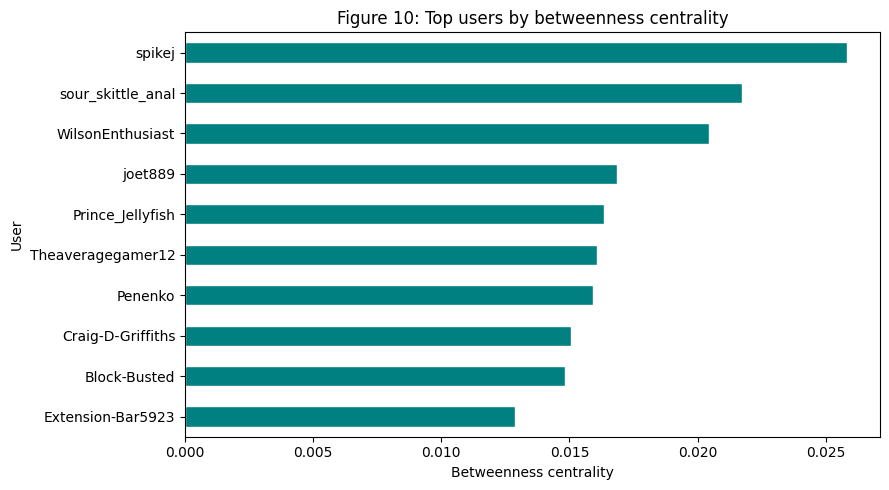

In [ ]:
top_brokers = centrality_df.head(10)

fig, ax = plt.subplots(figsize=(9, 5))

top_brokers.sort_values("betweenness_centrality").plot(
    kind="barh",
    x="user",
    y="betweenness_centrality",
    ax=ax,
    color=STRIKE_COLOR,
    edgecolor="white",
    legend=False
)

ax.set_title("Figure 10: Top users by betweenness centrality", fontsize=12)
ax.set_xlabel("Betweenness centrality")
ax.set_ylabel("User")

plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig10_top_brokers.png", dpi=150, bbox_inches="tight")
plt.show()

The visualization reveals a relatively small group of users with substantially higher betweenness centrality than the rest of the network. Their importance does not necessarily derive from posting more content, but rather from connecting different groups of participants and facilitating information flow.

The concentration of betweenness among a limited number of users suggests that communication within the network was partially dependent on a small set of brokerage actors who helped connect different discussion clusters.

To move beyond aggregate network statistics, we examine the individual users who occupy the most structurally important positions in the discussion network. We call Broker users, those with the highest betweenness centrality. For each top-10 broker, we identify their most active subreddit and, where available, their dominant frame from the submissions dataset.

In [ ]:
# Merge broker info with subreddit and frame
broker_users = centrality_df.head(10)[["user", "betweenness_centrality"]]

# Get subreddit: most frequent subreddit in their comments
broker_subreddit = (
    df_comments[df_comments["author"].isin(broker_users["user"])]
    .groupby("author")["subreddit"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"author": "user", "subreddit": "top_subreddit"})
)

# Get frame: from submissions where they are the author
broker_frame = (
    df[df["author"].isin(broker_users["user"])]
    .groupby("author")["dominant_frame"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"author": "user", "dominant_frame": "top_frame"})
)

broker_profile = (
    broker_users
    .merge(broker_subreddit, on="user", how="left")
    .merge(broker_frame, on="user", how="left")
    .fillna("n/a")
)

broker_n_subreddits = (
    df_comments[df_comments["author"].isin(broker_users["user"])]
    .groupby("author")["subreddit"]
    .nunique()
    .reset_index()
    .rename(columns={"author": "user", "subreddit": "n_subreddits_active"})
)

broker_profile = broker_profile.merge(broker_n_subreddits, on="user", how="left")
print(broker_profile.to_string(index=False))

             user  betweenness_centrality top_subreddit               top_frame  n_subreddits_active
           spikej                0.025825 Screenwriting authenticity_creativity                    1
sour_skittle_anal                0.021728 Screenwriting                     n/a                    1
 WilsonEnthusiast                0.020438 Screenwriting                     n/a                    2
          joet889                0.016855 Screenwriting                     n/a                    1
 Prince_Jellyfish                0.016351 Screenwriting          workers_rights                    1
Theaveragegamer12                0.016073        movies          workers_rights                    1
          Penenko                0.015908 Screenwriting          workers_rights                    1
Craig-D-Griffiths                0.015049 Screenwriting                     n/a                    1
     Block-Busted                0.014838    artificial authenticity_creativity            

Most of the identified brokers appear to be concentrated within a single subreddit, particularly `r/Screenwriting`. This suggests that brokerage in this network was often driven by influential participants within communities.

Where frame information is available, several brokers are associated with `authenticity_creativity`, `workers_rights`, or `replacement_anxiety`, indicating that influential users frequently participated in discussions concerning creative labor and the impact of AI on professional work.

### **5.3 Community Detection**
Community detection is applied to the undirected version of the reply network using the Louvain algorithm. The goal is to identify groups of users who interact more frequently with each other than with the rest of the network.

These detected communities will later be compared with content frames to understand whether different network communities also differ in how they frame AI.

In [ ]:
# Convert to undirected graph for Louvain community detection
G_undirected = G.to_undirected()

# Keep largest connected component for clearer community detection
largest_component = max(nx.connected_components(G_undirected), key=len)
G_comm = G_undirected.subgraph(largest_component).copy()

partition = community_louvain.best_partition(G_comm, weight="weight", random_state=42)

# Add community labels to nodes
nx.set_node_attributes(G_comm, partition, "community")

community_df = pd.DataFrame({
    "user": list(partition.keys()),
    "community": list(partition.values())
})

print(f"Number of detected communities: {community_df['community'].nunique()}")
print("\nCommunity sizes:")
print(community_df["community"].value_counts().head(10).to_string())

Number of detected communities: 33

Community sizes:
community
25    106
31     87
23     70
21     66
15     62
5      58
11     57
27     56
16     55
3      55



The Louvain community detection algorithm identified 33 distinct communities within the interaction network.
Community sizes vary substantially, with a small number of relatively large clusters and many smaller groups.


Modularity measures how clearly separated the detected communities are. Higher values indicate that users interact more within their own community than with users outside it. This helps evaluate whether the community structure is meaningful.

In [ ]:
modularity = community_louvain.modularity(partition, G_comm, weight="weight")

print(f"Louvain modularity: {modularity:.4f}")

Louvain modularity: 0.8672


The network exhibits a very high modularity score (0.8672), indicating a strongly segmented community structure.

Users interacted far more frequently within their own communities than across community boundaries.


In [ ]:
# Characterize each community by its dominant subreddit and phase.
df_comments_comm = df_comments.merge(
    community_df, left_on="author", right_on="user", how="inner"
)

community_profile = df_comments_comm.groupby("community").agg(
    size=("author", "count"),
    top_subreddit=("subreddit", lambda x: x.value_counts().index[0]),
    top_phase=("phase", lambda x: x.value_counts().index[0])
).sort_values("size", ascending=False)

print("Community profiles (top 10 by size):")
print(community_profile.head(10).to_string())

Community profiles (top 10 by size):
           size  top_subreddit    top_phase
community                                  
25          286  Screenwriting       strike
5           231  Screenwriting   pre-strike
15          171     television       strike
21          170     artificial       strike
3           151     artificial       strike
31          150         movies  post-strike
29          136     television  post-strike
9           132  Screenwriting       strike
4           131  Screenwriting   pre-strike
1           119  Screenwriting       strike


Detected network communities are not randomly distributed across subreddits. Several of the largest communities are strongly associated with `r/Screenwriting`, while others are primarily linked to `r/artificial`, `r/movies`, or `r/television`.

The results indicate that interaction patterns were influenced also by broader community identities and shared discussion environments.

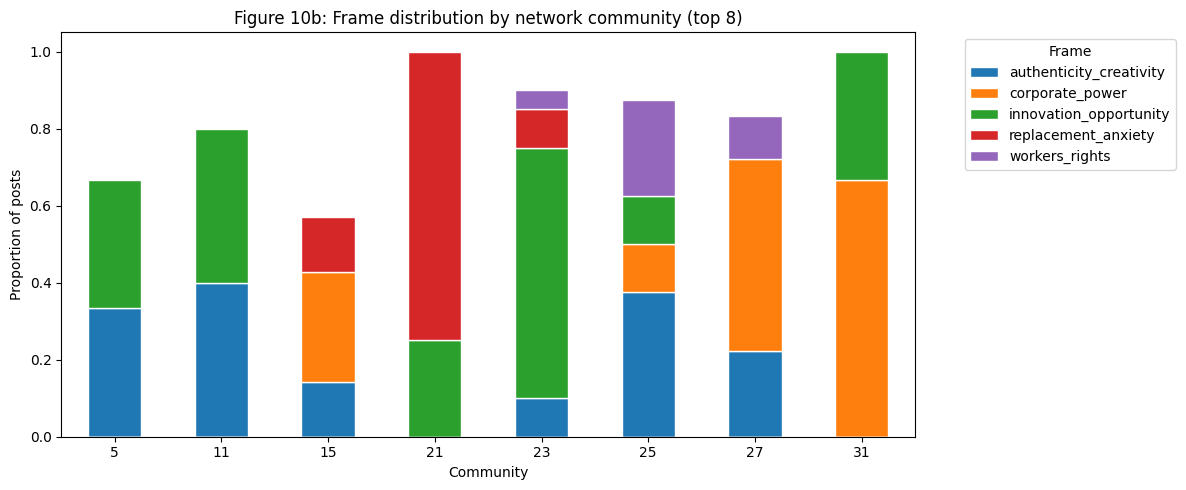

In [ ]:
# Merge community labels with frame data
df_with_community = df.merge(
    community_df, left_on="author", right_on="user", how="inner"
)

# Keep only top 8 communities by size
top_communities = community_df["community"].value_counts().head(8).index
df_top_comm = df_with_community[df_with_community["community"].isin(top_communities)]

community_frame_crosstab = pd.crosstab(
    df_top_comm["community"],
    df_top_comm["dominant_frame"],
    normalize="index"
)

fig, ax = plt.subplots(figsize=(12, 5))
community_frame_crosstab.drop(
    columns=["unclassified", "mixed"], errors="ignore"
).plot(kind="bar", stacked=True, ax=ax, edgecolor="white")
ax.set_title("Figure 11: Frame distribution by network community (top 8)", fontsize=12)
ax.set_xlabel("Community")
ax.set_ylabel("Proportion of posts")
plt.xticks(rotation=0)
plt.legend(title="Frame", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig11_community_frames.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 11 shows that structurally distinct communities also differ substantially in their dominant AI frames.

The coexistence of multiple framing patterns across communities suggests that the broader debate was composed of several parallel conversations, each emphasizing different aspects of the relationship between AI, creative work, and the entertainment industry.

In [ ]:
# Network visualization: top 300 nodes by betweenness centrality.

# Select top nodes for visualization
top_nodes = set(centrality_df.head(300)["user"].tolist())
G_vis = G_comm.subgraph(
    [n for n in G_comm.nodes() if n in top_nodes]
).copy()

# Assign colors by community
communities_in_vis = [partition.get(n, 0) for n in G_vis.nodes()]
unique_comms = sorted(set(communities_in_vis))
color_map = {
    c: "#{:02x}{:02x}{:02x}".format(
        int(r*255), int(g*255), int(b*255)
    )
    for c, (r, g, b, _) in zip(
        unique_comms,
        cm.tab20(range(len(unique_comms)))
    )
}

# Build interactive graph
net = Network(
    height="650px",
    width="100%",
    bgcolor="white",
    directed=False,
    notebook=True,
    cdn_resources="in_line"
)
net.repulsion(node_distance=120, spring_length=200)

for node in G_vis.nodes():
    comm = partition.get(node, 0)
    bc = betweenness_centrality.get(node, 0)
    net.add_node(
        node,
        color=color_map.get(comm, "#cccccc"),
        size=8 + bc * 500,
        title=f"User: {node}\nCommunity: {comm}\nBetweenness: {bc:.4f}"
    )

for u, v, data in G_vis.edges(data=True):
    net.add_edge(u, v, width=data.get("weight", 1) * 0.5)

graph_path = DRIVE_PATH_IMAGES + "fig12a_network_graph.html"
net.save_graph(graph_path)
print(f"Interactive graph saved to: {graph_path}")
print("Open the HTML file to explore the network interactively.")

Interactive graph saved to: /content/drive/MyDrive/WSA_Camera_Miele/figures/fig12a_network_graph.html
Open the HTML file to explore the network interactively.


In [ ]:
from IPython.display import display, HTML

graph_path = "/content/fig11_network_graph.html"
net.save_graph(graph_path)

with open(graph_path, "r") as f:
    html_content = f.read()

display(HTML(html_content))

# Poi salva anche su Drive
import shutil
shutil.copy(graph_path, DRIVE_PATH_IMAGES + "fig12a_network_graph.html")
print(f" Graph saved to Drive")

 Graph saved to Drive


Figure 12a visualizes the reply network colored according to the communities identified by the Louvain algorithm. Each node represents a Reddit user, while edges represent reply interactions between users.

Node size is proportional to betweenness centrality, making structurally important brokers more visible. The clear separation between colored clusters is consistent with the high modularity observed earlier and confirms that discussions were organized into relatively distinct conversational groups.

The visualization suggests that most interactions occurred within communities rather than across them, reinforcing the interpretation of a socially fragmented debate around AI and the Hollywood Strike.

In [ ]:
# identify the dominant subreddit
community_subreddit = (
    df_comments[df_comments["author"].isin(community_df["user"])]
    .merge(community_df, left_on="author", right_on="user")
    .groupby("community")["subreddit"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={"subreddit": "dominant_subreddit"})
)

print(community_subreddit.sort_values("community").to_string(index=False))

 community dominant_subreddit
         0             movies
         1      Screenwriting
         2      Screenwriting
         3         artificial
         4      Screenwriting
         5      Screenwriting
         6      Screenwriting
         7      Screenwriting
         8      Screenwriting
         9      Screenwriting
        10             movies
        11             movies
        12         artificial
        13      Screenwriting
        14         television
        15         television
        16         television
        17         television
        18             movies
        19         television
        20         television
        21         artificial
        22             movies
        23         artificial
        24      Screenwriting
        25      Screenwriting
        26             movies
        27             movies
        28         television
        29         television
        30         television
        31             movies
        32

The dominant subreddit associated with each detected community reveals that many communities are strongly aligned with a specific discussion space.

`r/Screenwriting` accounts for a large share of the identified communities, reflecting the central role of professional writers within the broader debate. At the same time, separate communities emerge around `r/artificial`, `r/movies`, and `r/television`, indicating that different audiences developed partially independent conversational structures.


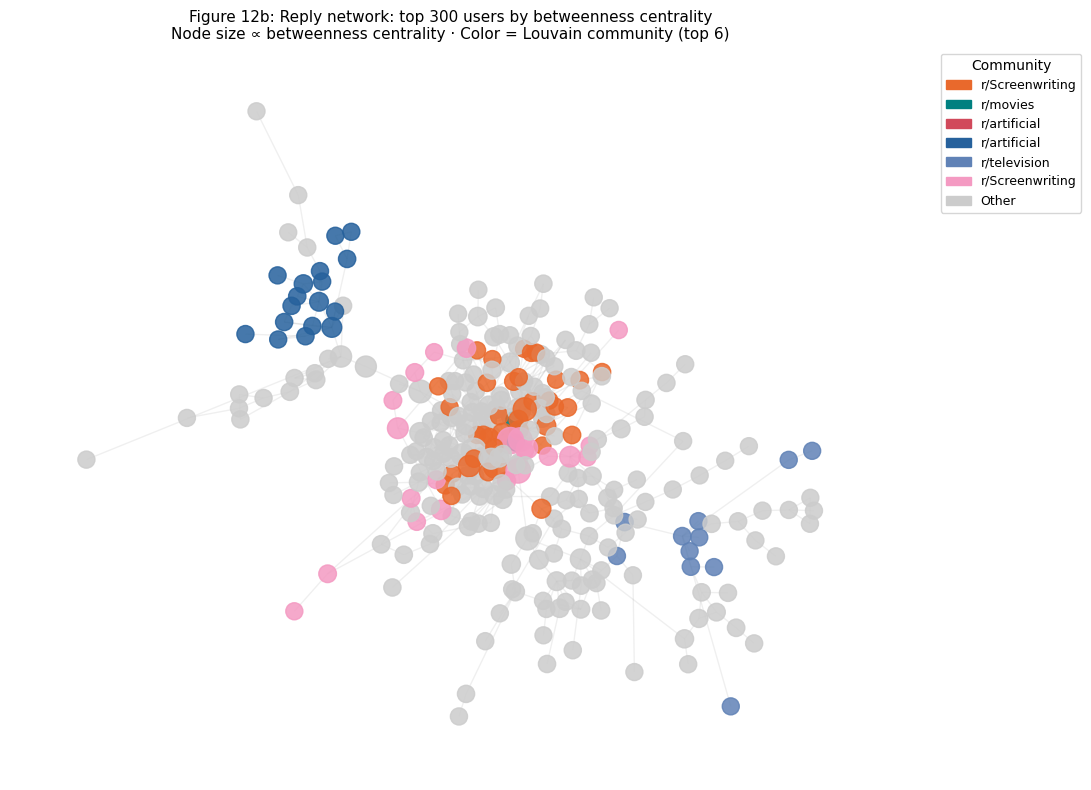

In [ ]:
top_communities = community_df["community"].value_counts().head(6).index.tolist()

fixed_colors = {
    c: col for c, col in zip(
        top_communities,
        ["#E9692C", "#008080", "#D1495B", "#26619C", "#6082B6", "#F49AC2"]
    )
}

def get_color(node):
    c = partition.get(node, -1)
    return fixed_colors.get(c, "#cccccc")

node_colors = [get_color(n) for n in G_vis.nodes()]
node_sizes = [min(150 + betweenness_centrality.get(n, 0) * 8000, 800) for n in G_vis.nodes()]

pos = nx.kamada_kawai_layout(G_vis)

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_nodes(G_vis, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.12,
                       edge_color="grey", arrows=False)

community_labels = dict(
    zip(
        community_subreddit["community"],
        community_subreddit["dominant_subreddit"]
    )
)

community_labels = {
    k: f"r/{v}"
    for k, v in community_labels.items()
}

patches = [
    mpatches.Patch(color=fixed_colors[c], label=community_labels.get(c, f"Community {c}"))
    for c in top_communities
] + [mpatches.Patch(color="#cccccc", label="Other")]

ax.legend(handles=patches, bbox_to_anchor=(1.05, 1),
          loc="upper left", fontsize=9, title="Community")
ax.set_title(
    "Figure 12b: Reply network: top 300 users by betweenness centrality\n"
    "Node size ∝ betweenness centrality · Color = Louvain community (top 6)",
    fontsize=11
)
ax.axis("off")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig12b_network_static.png", dpi=150, bbox_inches="tight")
plt.show()

Figure 12b provides a simplified visualization of the 300 users with the highest betweenness centrality, highlighting the most structurally important portion of the network.

The largest communities occupy distinct regions of the graph, confirming the strong community structure previously identified through modularity analysis. While some overlap exists near the center of the network, most highly connected users remain embedded within their own clusters.

The visualization suggests that information flow was concentrated around a limited set of influential users positioned near the boundaries between communities. These users likely played an important role in connecting otherwise separate discussion spaces and facilitating the circulation of narratives across the broader debate.

### **5.4 Temporal Evolution**
To assess whether the community structure changed across the three phases of the Hollywood Strike, the Louvain community detection algorithm is applied separately to each temporal subgraph. Each subgraph contains only the reply interactions that occurred during that phase. Comparing modularity scores and community counts across phases allows us to test whether the strike period produced a more fragmented or more cohesive discussion structure.

In [ ]:
# Temporal network analysis: community detection per phase.
temporal_results = {}

for phase in ["pre-strike", "strike", "post-strike"]:

    # Filter edges for this phase
    phase_edges = edges_df[edges_df["phase"] == phase]

    if len(phase_edges) < 10:
        print(f"[SKIP] {phase}: too few edges ({len(phase_edges)})")
        continue

    # Build undirected weighted graph for this phase
    G_phase = nx.Graph()
    for _, row in phase_edges.iterrows():
        if G_phase.has_edge(row["source"], row["target"]):
            G_phase[row["source"]][row["target"]]["weight"] += 1
        else:
            G_phase.add_edge(row["source"], row["target"], weight=1)

    # Keep largest connected component
    lcc_phase = max(nx.connected_components(G_phase), key=len)
    G_phase_lcc = G_phase.subgraph(lcc_phase).copy()

    # Community detection
    partition_phase = community_louvain.best_partition(
        G_phase_lcc, weight="weight", random_state=42
    )
    modularity_phase = community_louvain.modularity(
        partition_phase, G_phase_lcc, weight="weight"
    )

    temporal_results[phase] = {
        "nodes": G_phase.number_of_nodes(),
        "edges": G_phase.number_of_edges(),
        "lcc_size": len(lcc_phase),
        "communities": len(set(partition_phase.values())),
        "modularity": round(modularity_phase, 4)
    }

    print(f"\n── {phase} ──")
    print(f"  Nodes:       {G_phase.number_of_nodes()}")
    print(f"  Edges:       {G_phase.number_of_edges()}")
    print(f"  LCC size:    {len(lcc_phase)}")
    print(f"  Communities: {len(set(partition_phase.values()))}")
    print(f"  Modularity:  {modularity_phase:.4f}")


── pre-strike ──
  Nodes:       246
  Edges:       251
  LCC size:    81
  Communities: 8
  Modularity:  0.6892

── strike ──
  Nodes:       1015
  Edges:       1056
  LCC size:    661
  Communities: 27
  Modularity:  0.8816

── post-strike ──
  Nodes:       1564
  Edges:       1307
  LCC size:    506
  Communities: 23
  Modularity:  0.8762


      phase  nodes  edges  lcc_size  communities  modularity
 pre-strike  246.0  251.0      81.0          8.0      0.6892
     strike 1015.0 1056.0     661.0         27.0      0.8816
post-strike 1564.0 1307.0     506.0         23.0      0.8762


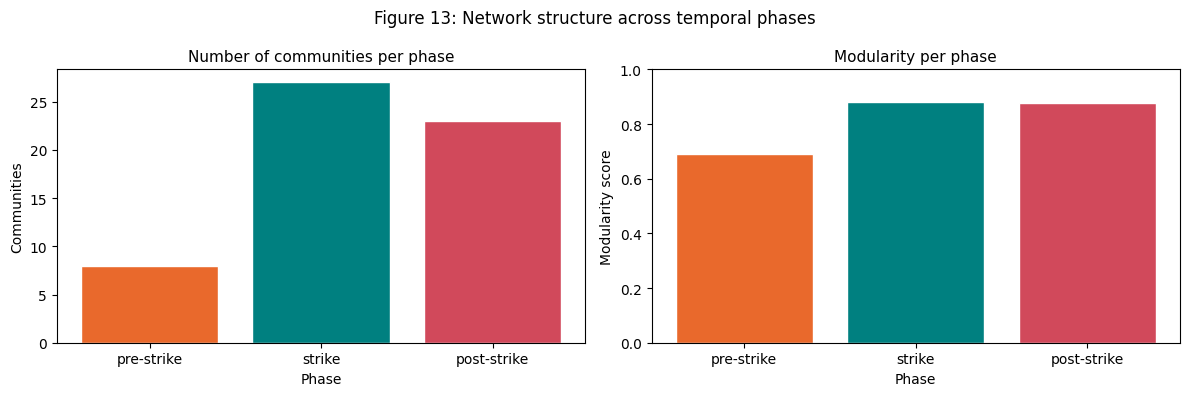

In [ ]:
# Visualize temporal network metrics as a summary table and bar chart

temporal_df = pd.DataFrame(temporal_results).T.reset_index()
temporal_df.columns = ["phase", "nodes", "edges", "lcc_size", "communities", "modularity"]
temporal_df["phase"] = pd.Categorical(
    temporal_df["phase"],
    categories=["pre-strike", "strike", "post-strike"],
    ordered=True
)
temporal_df = temporal_df.sort_values("phase")

print(temporal_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Communities per phase
axes[0].bar(
    temporal_df["phase"],
    temporal_df["communities"],
    color=[PRE_COLOR, STRIKE_COLOR, POST_COLOR],
    edgecolor="white"
)
axes[0].set_title("Number of communities per phase", fontsize=11)
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("Communities")

# Modularity per phase
axes[1].bar(
    temporal_df["phase"],
    temporal_df["modularity"],
    color=[PRE_COLOR, STRIKE_COLOR, POST_COLOR],
    edgecolor="white"
)
axes[1].set_title("Modularity per phase", fontsize=11)
axes[1].set_xlabel("Phase")
axes[1].set_ylabel("Modularity score")
axes[1].set_ylim(0, 1)

plt.suptitle("Figure 13: Network structure across temporal phases", fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig13_temporal_network.png", dpi=150, bbox_inches="tight")
plt.show()

The number of communities increases dramatically from 8 before the strike to 27 during the strike, indicating that the conflict stimulated the emergence of many distinct conversational groups. Community count remains relatively high after the strike, suggesting that several discussion clusters persisted even after the labor dispute ended.

Modularity also increases substantially from the pre-strike period (0.689) to both the strike (0.882) and post-strike phases (0.874). This indicates that users interacted increasingly within their own communities rather than across community boundaries, producing a more segmented and polarized conversational structure.

In [ ]:
for phase in ["pre-strike", "strike", "post-strike"]:
    phase_edges = edges_df[edges_df["phase"] == phase].copy()
    if len(phase_edges) == 0:
        continue

    # Add subreddit for source and target
    author_subreddit = df_comments.groupby("author")["subreddit"].agg(
        lambda x: x.value_counts().index[0]
    ).to_dict()

    phase_edges["source_subreddit"] = phase_edges["source"].map(author_subreddit)
    phase_edges["target_subreddit"] = phase_edges["target"].map(author_subreddit)

    cross = (phase_edges["source_subreddit"] != phase_edges["target_subreddit"]).mean()
    print(f"{phase}: {cross:.1%} cross-subreddit edges")

pre-strike: 15.5% cross-subreddit edges
strike: 14.6% cross-subreddit edges
post-strike: 12.4% cross-subreddit edges


Cross-subreddit interaction decreases steadily throughout the three phases of the discussion. Before the strike, approximately 15.5% of interactions connected users belonging to different subreddits. This proportion falls to 14.6% during the strike and declines further to 12.4% in the post-strike period.

The results suggest that users increasingly interacted within their own subreddit communities rather than engaging with participants from other discussion spaces. This pattern is consistent with the high modularity observed throughout the network and reinforces the interpretation of a debate organized around relatively distinct audience groups.

To further characterize how interaction patterns evolved across phases, degree assortativity is computed for each temporal subgraph. Degree assortativity measures whether users with similar levels of activity tend to interact with each other. A positive value indicates that highly active users reply predominantly to other highly active users; a negative value indicates that active users tend to interact with peripheral ones, which is more typical of hub-and-spoke structures common in online discussions.

In [ ]:
print("Degree assortativity by phase:")
print("=" * 40)

for phase in ["pre-strike", "strike", "post-strike"]:
    phase_edges = edges_df[edges_df["phase"] == phase]

    if len(phase_edges) == 0:
        print(f"{phase}: no edges found")
        continue

    G_phase = nx.from_pandas_edgelist(
        phase_edges,
        source="source",
        target="target",
        create_using=nx.DiGraph()
    )

    # using total degree (in+out) as default for DiGraph
    r = nx.degree_assortativity_coefficient(G_phase)
    print(f"{phase:>12}: r = {r:.4f}")

Degree assortativity by phase:
  pre-strike: r = -0.3017
      strike: r = -0.2251
 post-strike: r = -0.1123


Degree assortativity is negative across all three phases, consistent with the disassortative structure typical of online discussion networks: highly active users tend to interact with peripheral ones rather than among themselves, producing a hub-and-spoke pattern. Notably, the values become less negative over time (pre-strike: −0.30, strike: −0.23, post-strike: −0.11), suggesting that the hub-and-spoke structure gradually weakened as the discussion expanded. During the post-strike phase, interaction became slightly more distributed, with active users engaging more with other active users rather than concentrating exclusively on peripheral participants. This may reflect the gradual stabilization of the discussion as the debate moved from the active strike period to the post-strike phase.



The edge list and user-level network metrics are saved for later analysis and visualization. These files can also be imported into external visualization tools such as Gephi.

In [ ]:
# Merge centrality and community labels
network_users_df = centrality_df.merge(
    community_df,
    on="user",
    how="left"
)

edges_path = DRIVE_PATH + "reply_network_edges.csv"
users_path = DRIVE_PATH + "reply_network_users.csv"

edges_df.to_csv(edges_path, index=False)
network_users_df.to_csv(users_path, index=False)

print(f"Edges saved to: {edges_path}")
print(f"User metrics saved to: {users_path}")

network_users_df.head()

Edges saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/reply_network_edges.csv
User metrics saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/reply_network_users.csv


,user,in_degree_centrality,out_degree_centrality,betweenness_centrality,community
0,spikej,0.004845,0.002609,0.025825,5.0
1,sour_skittle_anal,0.002609,0.002609,0.021728,6.0
2,WilsonEnthusiast,0.001491,0.002609,0.020438,5.0
3,joet889,0.002609,0.002982,0.016855,5.0
4,Prince_Jellyfish,0.010436,0.007827,0.016351,4.0


## **6. Content Analysis**

While frame detection isolates the dominant interpretive lenses utilized by these communities, it does not capture the emotional valence underpinning the discourse. To reveal the underlying affect, this section deploys deep-learning Sentiment Analysis alongside Named Entity Recognition (NER). By crossing semantic framing with emotional metrics and focal entities, we unpack not just what was discussed, but how it was emotionally charged and which actors centered the debate.

### **6.1 Sentiment Analysis**

To process social media text effectively, we utilize `cardiffnlp/twitter-roberta-base-sentiment`, a language model trained on roughly 58 million tweets. Its pre-training on short, opinion-heavy, and informal structures makes it highly compatible with Reddit's register. Unlike vocabulary-based metrics, the transformer evaluates contextual syntax, requiring natural, untokenized language input from the `full_text` vector.

In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment",
    max_length=512,
    truncation=True
)

LABEL_MAP = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

print("Sentiment model loaded: cardiffnlp/twitter-roberta-base-sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Sentiment model loaded: cardiffnlp/twitter-roberta-base-sentiment


The cleaned submissions dataset with frame labels is loaded as the input for this section.

In [ ]:
df = pd.read_csv(DRIVE_PATH + "submissions_with_frames.csv", parse_dates=["date"])
print(f"Dataset loaded: {len(df)} posts")

Dataset loaded: 255 posts


Sentiment analysis is applied to each post. Posts that exceed the model's 512-token context window are automatically truncated. Posts with missing or empty text are assigned a neutral label with zero confidence score.

The overall sentiment distribution provides a first picture of the emotional tone of the corpus. A prevalence of negative sentiment would be consistent with a debate dominated by concerns about labor displacement, corporate exploitation, and threats to creative authorship. Neutral sentiment is also expected to be significant, as many posts consist of shared news articles and informational content rather than direct opinion expression.

In [ ]:
def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return "neutral", 0.0
    try:
        result = sentiment_pipeline(text[:512])[0]
        label = LABEL_MAP.get(result["label"], result["label"])
        return label, round(result["score"], 4)
    except Exception:
        return "neutral", 0.0

print("Applying sentiment analysis... (this may take a few minutes)")
df[["sentiment", "sentiment_score"]] = df["full_text"].apply(
    lambda x: pd.Series(get_sentiment(x))
)
print("Done.")
print("\nSentiment distribution:")
print(df["sentiment"].value_counts().to_string())

Applying sentiment analysis... (this may take a few minutes)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done.

Sentiment distribution:
sentiment
neutral     140
negative     71
positive     44


The overall distribution is visualized below as a bar chart. Sentiment labels are ordered from most positive to most negative to facilitate visual interpretation.

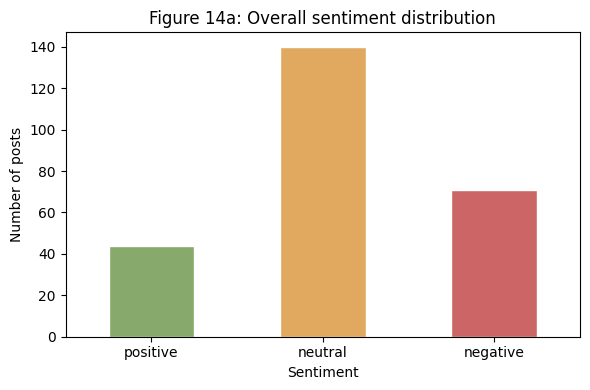

In [ ]:
sentiment_counts = df["sentiment"].value_counts().reindex(
    ["positive", "neutral", "negative"]
)

fig, ax = plt.subplots(figsize=(6, 4))
sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=['#87A96B', '#E1A95F', '#CC6666'],
    edgecolor="white"
)
ax.set_title("Figure 14a: Overall sentiment distribution", fontsize=12)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig14a_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Neutral sentiment dominates the corpus (140 posts), with negative sentiment (71 posts) outnumbering positive (44 posts). The high neutral share is consistent with the large proportion of news-sharing and informational posts in the dataset. Among posts with clear emotional valence, negative sentiment is more common, reflecting the predominantly critical stance toward AI adoption in creative industries.

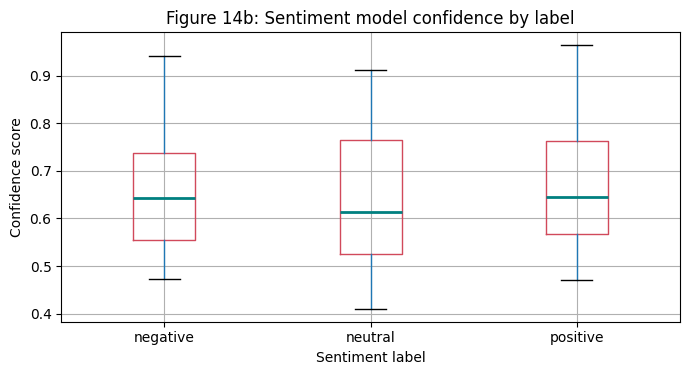

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(
    column="sentiment_score",
    by="sentiment",
    ax=ax,
    boxprops=dict(color=POST_COLOR),
    medianprops=dict(color=STRIKE_COLOR, linewidth=2)
)
ax.set_title("Figure 14b: Sentiment model confidence by label", fontsize=12)
ax.set_xlabel("Sentiment label")
ax.set_ylabel("Confidence score")
plt.suptitle("")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig14b_sentiment_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

The confidence distributions show that positive and negative classifications tend to have higher and more consistent scores, while neutral classifications display lower median values and greater spread. This suggests that the model identifies clearly polarized content with greater certainty, while neutral labels capture a more heterogeneous mix of factual and ambiguous posts.

We now compare sentiment distributions across subreddits. Communities with a stronger professional stake in the outcome of the strike, such as `r/Screenwriting`, are expected to show higher negative sentiment compared to technology-oriented communities such as `r/artificial`, where AI is more frequently discussed as an opportunity. Differences in sentiment across subreddits would reinforce the frame detection results from Section 4, providing convergent evidence that community identity shapes both the interpretive lens and the emotional tone of AI discourse.

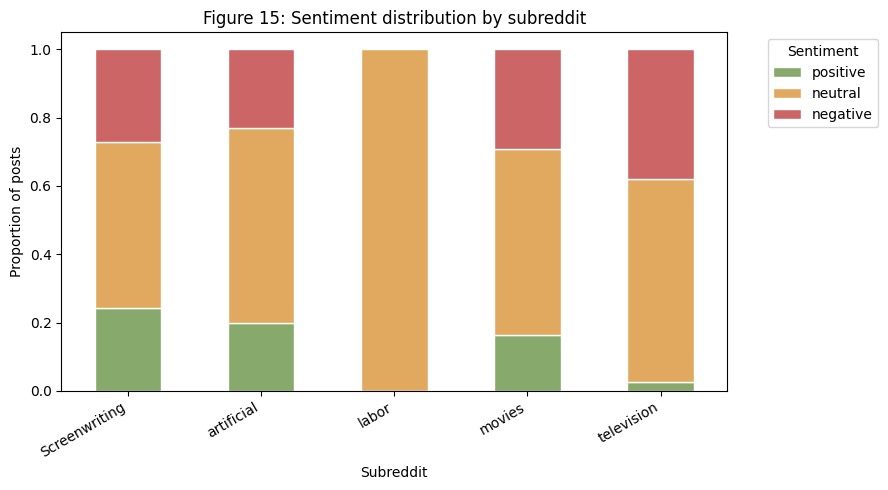

In [ ]:
sentiment_by_subreddit = pd.crosstab(
    df["subreddit"],
    df["sentiment"],
    normalize="index"
)[["positive", "neutral", "negative"]]

fig, ax = plt.subplots(figsize=(9, 5))
sentiment_by_subreddit.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=['#87A96B', '#E1A95F', '#CC6666'],
    edgecolor="white"
)
ax.set_title("Figure 15: Sentiment distribution by subreddit", fontsize=12)
ax.set_xlabel("Subreddit")
ax.set_ylabel("Proportion of posts")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig15_sentiment_by_subreddit.png", dpi=150, bbox_inches="tight")
plt.show()

The subreddit-level breakdown reveals meaningful differences in emotional tone. Negative sentiment is most prominent in `r/television` and `r/Screenwriting`, where AI-related concerns were more directly tied to professional stakes. In contrast, `r/artificial` displays lower negativity and a stronger neutral-to-positive distribution, consistent with its greater emphasis on the `innovation_opportunity` frame.

The temporal comparison tests whether the emotional tone of the discourse intensified during the strike period and whether it recovered after the agreements were reached. An increase in negative sentiment during the strike phase would be consistent with heightened anxiety about AI displacement and corporate exploitation. A partial shift toward neutral or positive sentiment in the post-strike phase would suggest that the resolution of the labor dispute reduced the perceived urgency of the AI threat within these communities.

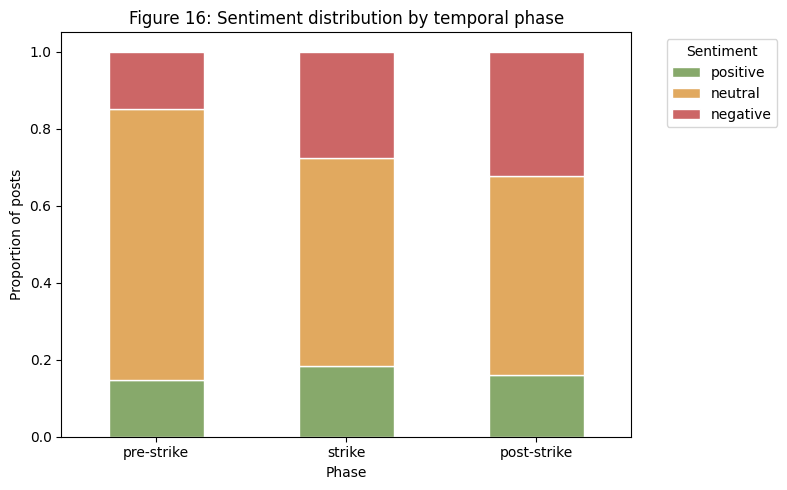

In [ ]:
sentiment_by_phase = pd.crosstab(
    df["phase"],
    df["sentiment"],
    normalize="index"
)[["positive", "neutral", "negative"]].reindex(
    ["pre-strike", "strike", "post-strike"]
)

fig, ax = plt.subplots(figsize=(8, 5))
sentiment_by_phase.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=['#87A96B', '#E1A95F', '#CC6666'],
    edgecolor="white"
)
ax.set_title("Figure 16: Sentiment distribution by temporal phase", fontsize=12)
ax.set_xlabel("Phase")
ax.set_ylabel("Proportion of posts")
plt.xticks(rotation=0)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig16_sentiment_by_phase.png", dpi=150, bbox_inches="tight")
plt.show()

The phase-level results show that negative sentiment increased steadily across the three periods, reaching its peak in the post-strike phase rather than during the strike itself. This suggests that the formal resolution of the dispute did not reduce critical engagement with AI. One plausible interpretation is that attention shifted from mobilization against the threat of AI toward evaluation of the protections negotiated in the final agreements.

To complement the phase-level comparison, sentiment is also examined at a finer temporal granularity. The following chart shows the monthly evolution of sentiment proportions across the full study period. This allows us to identify more precisely when shifts in emotional tone occurred relative to key events in the Hollywood Strike, rather than aggregating them into broad phases.

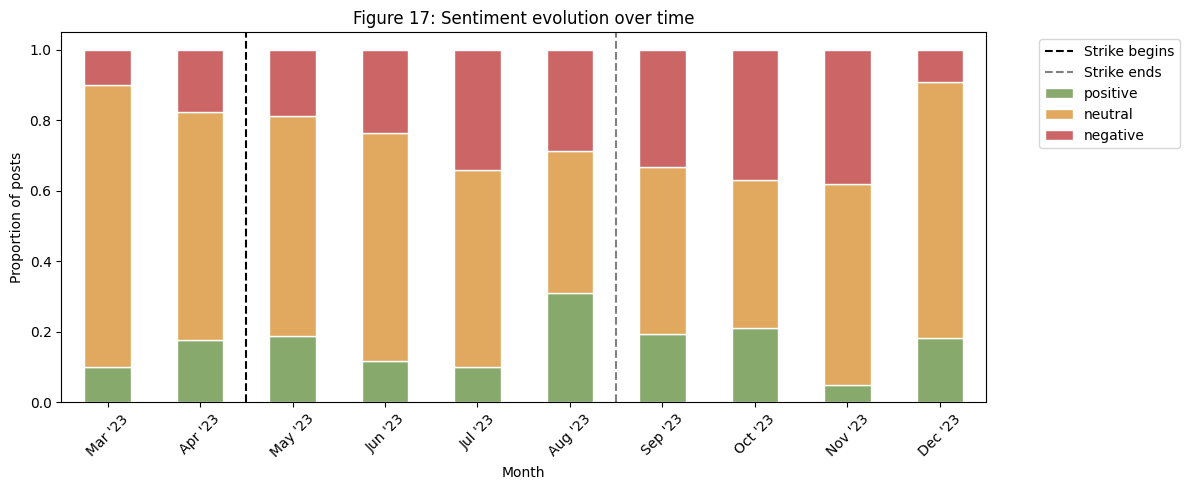

In [ ]:
df["month"] = df["date"].dt.to_period("M")

sentiment_timeline = df.groupby(["month", "sentiment"]).size().unstack(fill_value=0)
sentiment_timeline = sentiment_timeline.div(sentiment_timeline.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sentiment_timeline[["positive", "neutral", "negative"]].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=['#87A96B', '#E1A95F', '#CC6666'],
    edgecolor="white"
)
ax.axvline(x=1.5, color="black", linestyle="--", linewidth=1.5, label="Strike begins")
ax.axvline(x=5.5, color="grey", linestyle="--", linewidth=1.5, label="Strike ends")
ax.set_title("Figure 17: Sentiment evolution over time", fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Proportion of posts")

labels = [p.strftime("%b '%y") for p in sentiment_timeline.index.to_timestamp()]
ax.set_xticklabels(labels)

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig17_sentiment_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

The monthly breakdown shows that the increase in negative sentiment was not linear but concentrated in specific months, particularly October and November 2023. A temporary increase in positive sentiment is visible in August 2023, coinciding with the resumption of negotiations between studios and guilds.

Finally, sentiment is compared across the five dominant frames identified in Section 4. This cross-analysis tests whether different frames are associated with different emotional tones. Posts classified under `replacement_anxiety` are expected to carry stronger negative sentiment, while `innovation_opportunity` posts are expected to be more neutral or positive. Convergence between frame labels and sentiment scores would validate the internal coherence of the frame dictionaries. Posts labeled as `unclassified` or `mixed` are excluded from this comparison for clarity.

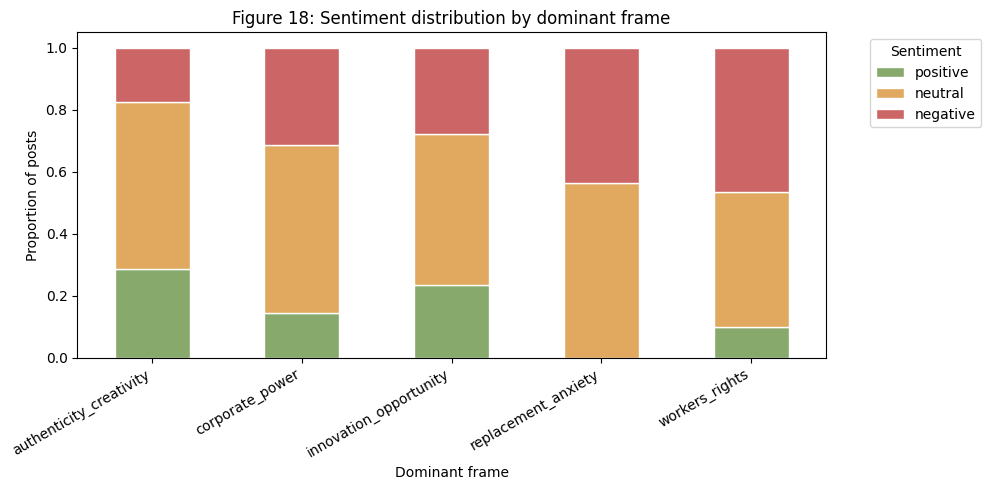

In [ ]:
sentiment_by_frame = pd.crosstab(
    df["dominant_frame"],
    df["sentiment"],
    normalize="index"
)[["positive", "neutral", "negative"]]

sentiment_by_frame = sentiment_by_frame.loc[
    ~sentiment_by_frame.index.isin(["unclassified", "mixed"])
]

fig, ax = plt.subplots(figsize=(10, 5))
sentiment_by_frame.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=['#87A96B', '#E1A95F', '#CC6666'],
    edgecolor="white"
)
ax.set_title("Figure 18: Sentiment distribution by dominant frame", fontsize=12)
ax.set_xlabel("Dominant frame")
ax.set_ylabel("Proportion of posts")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig18_sentiment_by_frame.png", dpi=150, bbox_inches="tight")
plt.show()

The sentiment distribution across frames is broadly consistent with theoretical expectations. Posts classified under `replacement_anxiety` and `workers_rights` show the highest proportion of negative sentiment, while `innovation_opportunity` is more neutral. `authenticity_creativity` shows a relatively higher positive share, suggesting that discussions about human authorship were not exclusively defensive but also affirmative of creative value. This convergence between frame labels and sentiment patterns supports the internal consistency of the frame dictionaries.

### **6.2 Named Entity Recognition**

While dictionary-based framing sets the thematic scope, Named Entity Recognition (NER) grounds the debate by identifying the actual actors, institutional bodies, and specific technologies anchoring the conversation. Rather than focusing on abstract language, NER extracts precise operational targets. This helps assess whether different subcultures within the strike debate anchored their concerns to the same key industry targets or shifted their focus toward separate entities.

We utilize spaCy's transformer-based pipeline `en_core_web_trf` for localized evaluation, falling back on `en_core_web_sm` if necessary. The extraction isolates three main entity groups: organizations (`ORG`), persons (`PERSON`), and technical products (`PRODUCT`).

In [ ]:
try:
    nlp_ner = spacy.load("en_core_web_trf")
    print("NER model: en_core_web_trf")
except OSError:
    nlp_ner = spacy.load("en_core_web_sm")
    print("NER model: en_core_web_sm (fallback)")

NER model: en_core_web_sm (fallback)


To optimize processing times over long text blocks while retaining critical introductory context, entity parsing is restricted to the first 1,000 characters of each submission.

In [ ]:
def extract_entities(text, entity_types=["ORG", "PERSON", "PRODUCT"]):
    if not isinstance(text, str) or text.strip() == "":
        return []
    doc = nlp_ner(text[:1000])
    return [
        (ent.text.strip(), ent.label_)
        for ent in doc.ents
        if ent.label_ in entity_types
        and len(ent.text.strip()) > 1
    ]

print("Applying NER... (this may take several minutes)")
df["entities"] = df["full_text"].apply(extract_entities)
print(f"Done. Posts with at least one entity: {df['entities'].apply(len).gt(0).sum()}")

Applying NER... (this may take several minutes)
Done. Posts with at least one entity: 216


Social media corpora generate considerable entity noise, including parsing artifacts and low-frequency terms. To isolate meaningful patterns, we apply an empirical blacklist that discards uninformative web-scraping noise, generic conversational terms, and sparse individual mentions, keeping only functionally diagnostic actors.

In [ ]:
ENTITY_BLACKLIST = {
    "Ethan", "Jack", "Rankings", "Netflix Lists",
    "Screenwriter's Weekly News Wrap-up", "Screenwriter's News",
    "ScriptHub", "SeamlessStreaming", "SeamlessExpressive",
    "Click here", "AI Protections", "VFX", "CGI",
    "Billy Ray", "Billy Ray:*", "Billy Ray's",
    "Phillips", "IMF", "Indiana Jones", "Nicolas Cage",
    "Academy Award", "Nathan Fielder", "Duncan Crabtree-Ireland",
    "Writers Strike", "Generative AI", "Bing AI", "EU",
    "DGA", "SAG",
    "Screenwriter's Weekly News Wrap-up",
    "Screenwriter's News",
    "Click here](https://youpoll.me/list/4/",
    "Shattered Glass",
    "Slams Hollywood System",
    "IP", "BC", "ethan",
    "concerns &amp",
    "Seinfeld", "Tom Selleck",
}

df["entities"] = df["entities"].apply(
    lambda ents: [(e, t) for e, t in ents if e not in ENTITY_BLACKLIST]
)

print("Entity blacklist applied.")
print(f"Posts with at least one entity after cleaning: {df['entities'].apply(len).gt(0).sum()}")

Entity blacklist applied.
Posts with at least one entity after cleaning: 204


The most frequently mentioned entities across the full corpus are visualized below. This provides a global picture of which actors and institutions dominated the AI debate during the Hollywood Strike.

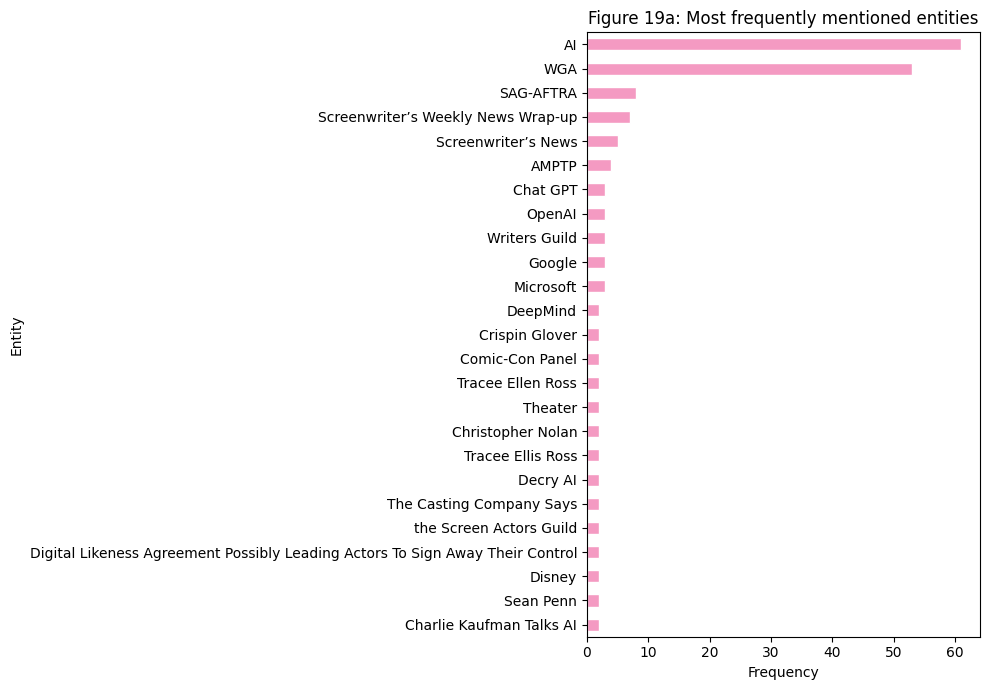

In [ ]:
all_entities = [
    ent for entities in df["entities"] for ent in entities
]

entity_df = pd.DataFrame(all_entities, columns=["entity", "type"])

top_entities = (
    entity_df.groupby(["entity", "type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 7))
top_entities.sort_values("count").plot(
    kind="barh",
    x="entity",
    y="count",
    ax=ax,
    color=ACCENT_COLOR,
    edgecolor="white",
    legend=False
)
ax.set_title("Figure 19a: Most frequently mentioned entities", fontsize=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("Entity")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig19a_top_entities.png", dpi=150, bbox_inches="tight")
plt.show()

The macro-distribution plotted shows that the aggregate discourse is heavily polarized around two main poles: the technology itself ("AI") and the primary institutional union driving the initial mobilization ("WGA"). Guild and studio bargaining units ("SAG-AFTRA", "AMPTP") follow closely, outlining the official framework of the collective bargaining dispute. On a technical level, specific product ecosystems ("Chat GPT", "OpenAI") emerge ahead of traditional legacy brands, indicating that the debate was grounded in the immediate disruptive capacity of LLMs rather than general technological abstractions

Crossing frame categories with localized entities reveals whether these interpretive lenses are tied to specific institutional actors. For our thematic setup to remain robust, the underlying discussions must anchor themselves to corresponding institutional fields. For instance, labor-centric frames should center on guild structures, while market-focused variants should track corporate organizations.

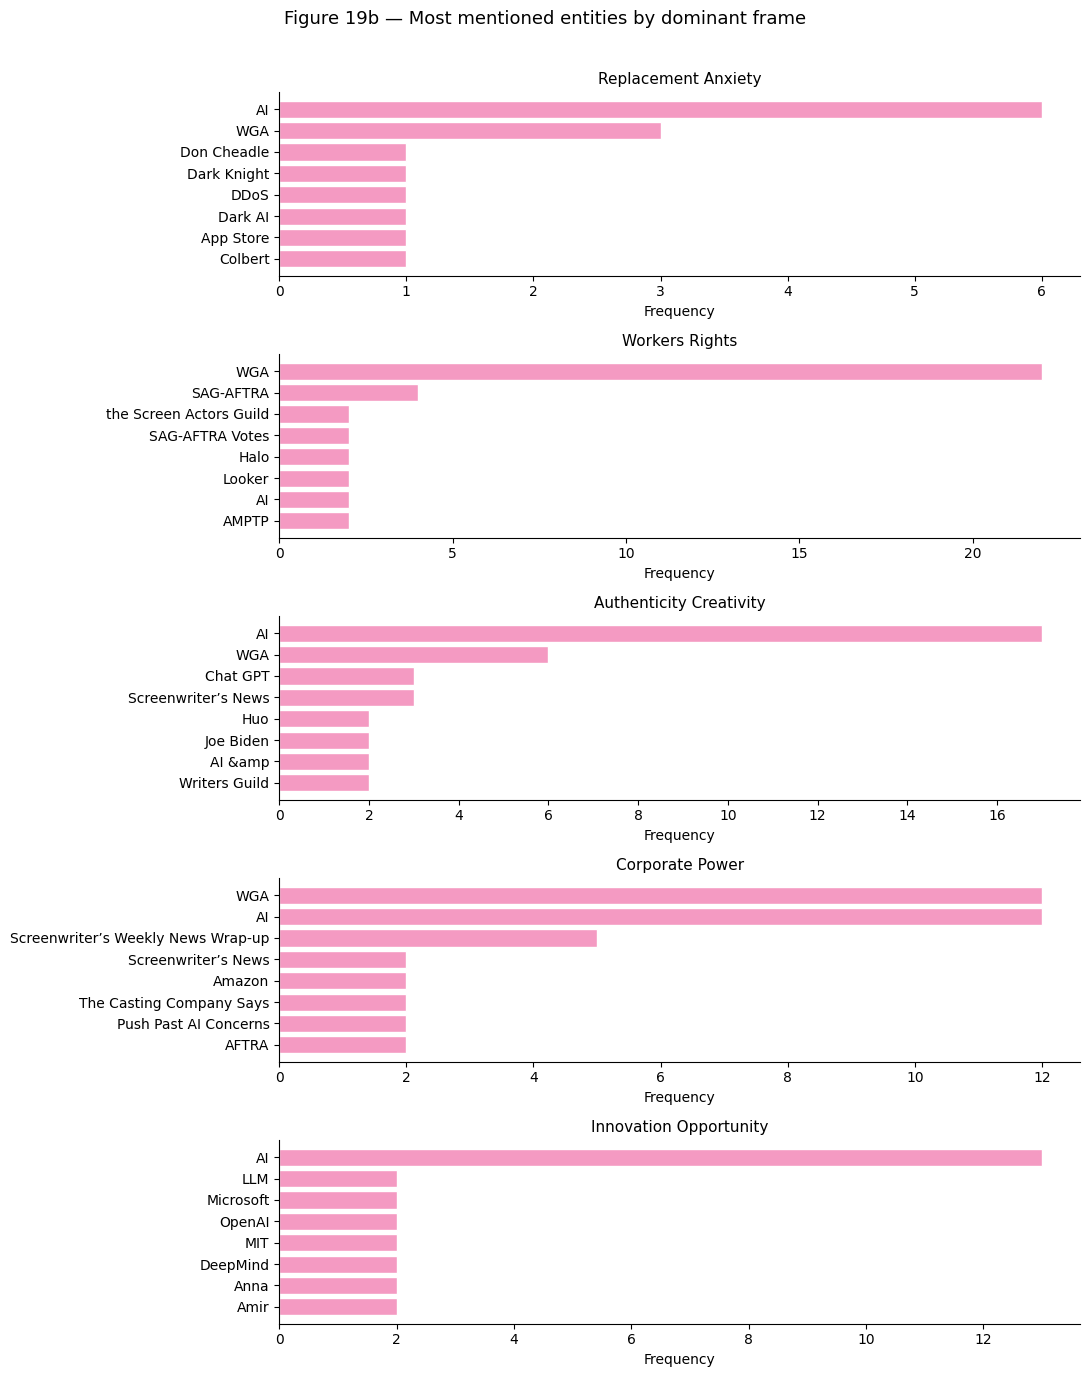

In [ ]:
# Entities per dominant frame
entity_by_frame = []

for _, row in df.iterrows():
    if row["dominant_frame"] in ["unclassified", "mixed"]:
        continue

    for ent, etype in row["entities"]:
        entity_by_frame.append({
            "frame": row["dominant_frame"],
            "entity": ent,
            "type": etype
        })

entity_frame_df = pd.DataFrame(entity_by_frame)

frames = list(FRAME_DICTIONARIES.keys())
fig, axes = plt.subplots(len(frames), 1, figsize=(11, 14), sharex=False)

for ax, frame in zip(axes, frames):
    top = (
        entity_frame_df[entity_frame_df["frame"] == frame]
        .groupby("entity")
        .size()
        .sort_values(ascending=False)
        .head(8)
        .reset_index(name="count")
    )

    if top.empty:
        ax.text(0.5, 0.5, "No entities found", ha="center", va="center")
        ax.set_title(frame.replace("_", " ").title(), fontsize=11, color="black")
        ax.axis("off")
        continue

    top = top.sort_values("count")

    ax.barh(top["entity"], top["count"], color=ACCENT_COLOR, edgecolor="white")
    ax.set_title(frame.replace("_", " ").title(), fontsize=11, color="black")
    ax.set_xlabel("Frequency", color="black")
    ax.set_ylabel("")
    ax.tick_params(colors="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Figure 19b — Most mentioned entities by dominant frame", fontsize=13, color="black")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(DRIVE_PATH_IMAGES + "fig19b_entities_by_frame.png", dpi=150, bbox_inches="tight")
plt.show()

The entity distributions across frames are largely consistent with their theoretical definitions. `workers_rights` centers almost exclusively on union organizations (WGA, SAG-AFTRA), while `corporate_power` combines union and AI references, framing technology as a tool of institutional power. `innovation_opportunity` is anchored to technology companies (OpenAI, Microsoft, DeepMind), and `authenticity_creativity` includes regulatory figures such as Joe Biden, suggesting that authorship debates extended into policy and legal discourse.

Entity mentions are then compared across subreddits to assess whether different communities centered their discussion on different actors. Communities with direct professional stakes in the strike outcome are expected to reference union organizations and studios more frequently, while technology-oriented communities are more likely to mention specific AI systems and companies.

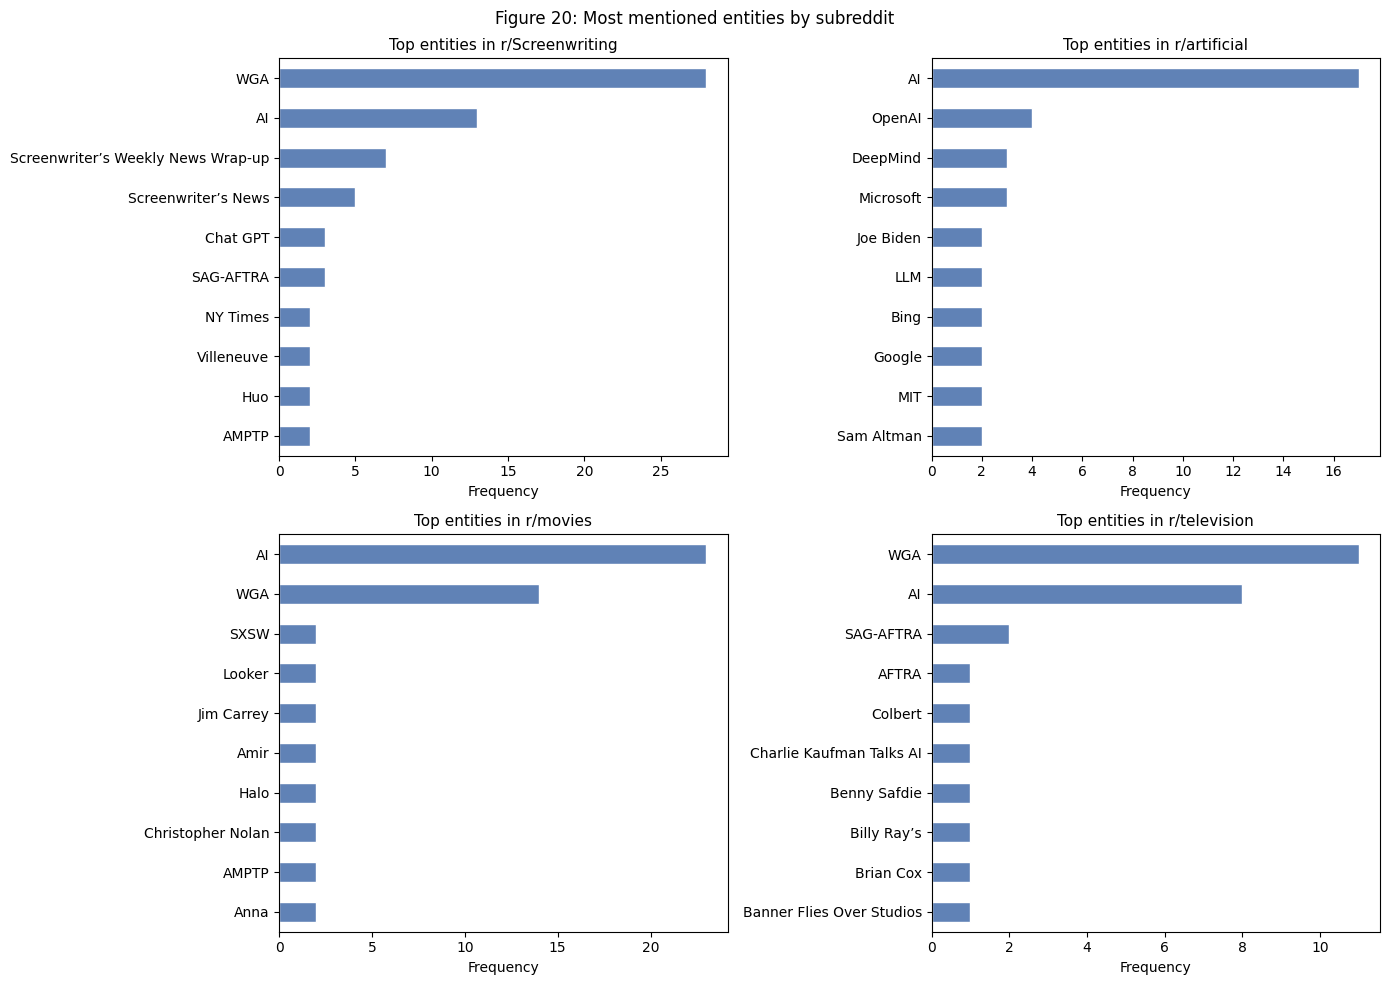

In [ ]:
entity_by_subreddit = []

for _, row in df.iterrows():
    for ent, etype in row["entities"]:
        entity_by_subreddit.append({
            "subreddit": row["subreddit"],
            "entity": ent,
            "type": etype
        })

entity_sub_df = pd.DataFrame(entity_by_subreddit)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, subreddit in zip(axes, ["Screenwriting", "artificial", "movies", "television"]):
    top = (
        entity_sub_df[entity_sub_df["subreddit"] == subreddit]
        .groupby("entity")
        .size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    top.columns = ["entity", "count"]

    if top.empty:
        ax.set_title(f"Top entities in r/{subreddit} (no data)", fontsize=11)
        ax.axis("off")
        continue

    top.sort_values("count").plot(
        kind="barh",
        x="entity",
        y="count",
        ax=ax,
        color=NEUTRAL_COLOR,
        edgecolor="white",
        legend=False
    )
    ax.set_title(f"Top entities in r/{subreddit}", fontsize=11)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

plt.suptitle("Figure 20: Most mentioned entities by subreddit", fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig20_entities_by_subreddit.png", dpi=150, bbox_inches="tight")
plt.show()

The subreddit-level entity distributions show meaningful differences in institutional focus. `r/Screenwriting` centers primarily on union organizations such as WGA, while `r/artificial` references technology companies more frequently, including OpenAI, DeepMind, and Microsoft. Entertainment communities such as `r/movies` and `r/television` show a more mixed distribution, combining institutional and individual references.

The final dataset, enriched with sentiment labels and entity annotations, is saved as `submissions_final.csv`. This file serves as the primary input for Section 7, where network communities are integrated with content features to provide a unified answer to the research question.

In [ ]:
df["entities_str"] = df["entities"].apply(
    lambda x: "|".join([f"{e[0]}::{e[1]}" for e in x])
)

output_path = DRIVE_PATH + "submissions_final.csv"
df.to_csv(output_path, index=False)

print(f"Final dataset saved to: {output_path}")
print(f"Rows: {len(df)}")
print(f"New columns: sentiment, sentiment_score, entities, entities_str")

Final dataset saved to: /content/drive/MyDrive/WSA_Camera_Miele/data/submissions_final.csv
Rows: 255
New columns: sentiment, sentiment_score, entities, entities_str


## **7. Integrated Community Analysis**
This section integrates the structural and content dimensions of the analysis. Network communities identified through reply interactions are mapped against the frame labels, sentiment scores, and entity annotations derived in the previous sections. The goal is to assess whether structurally distinct communities also differ in how they interpreted and discussed AI during the Hollywood Strike, and to provide a unified answer to the research question.

### **7.1 Mapping posts to network communities**

To evaluate the cross-sectional alignment between interaction patterns and semantic production, submission authors are structurally mapped to their respective Louvain network modules. Posts authored by users who did not engage in explicit reply-based threads are excluded from community-level profiling to preserve the statistical boundaries of the relational graph.

In [ ]:
# Keep only user-community mapping
user_community = network_users_df[["user", "community"]].dropna()

# Merge post authors with their detected network community
df_posts_comm = df_posts.merge(
    user_community,
    left_on="author",
    right_on="user",
    how="left"
)

print(f"Posts before community mapping: {len(df_posts_comm)}")
print(f"Posts with assigned community:  {df_posts_comm['community'].notna().sum()}")
print(f"Posts without community:        {df_posts_comm['community'].isna().sum()}")

df_posts_comm.head(3)

Posts before community mapping: 255
Posts with assigned community:  160
Posts without community:        95


,id,subreddit,query_key,query,title,text,author,score,upvote_ratio,num_comments,...,tokens_str,token_count,replacement_anxiety,workers_rights,authenticity_creativity,corporate_power,innovation_opportunity,dominant_frame,user,community
0,11g1iex,artificial,q06_replacement_1,AI actors,The editologic of deepfake Joe Biden,# The editologic of deepfake Joe Biden\n\n**EV...,walt74,2,0.60,0,...,editologic deepfake joe biden editologic deepf...,434,2,3,14,2,5,authenticity_creativity,NaN,NaN
1,11p8bk4,labor,q06_replacement_1,AI actors,End Labor Exploitation in The Acting Industry,**It’s A Big Club And You Ain't in It: How Pay...,HeightThese1554,1,1.00,0,...,labor exploitation act industry club ain pay p...,337,10,10,14,8,1,authenticity_creativity,NaN,NaN
2,11vjv2r,movies,q06_replacement_1,AI actors,"When AI gets to where it can generate movies, ...",AI is advancing so fast it is conceivable that...,couchdollarz,0,0.28,16,...,get generate movie exist cancel movie generate...,30,0,0,1,0,7,innovation_opportunity,couchdollarz,0.0


Of the 255 submissions, 160 could be mapped to a network community through author matching. The remaining 95 posts belong to authors who did not participate in reply interactions and therefore have no community assignment. These posts are retained in the dataset but excluded from community-level comparisons in this section.

### **7.2 Filtering relevant communities**

Online interaction networks naturally generate highly fragmented tail distributions, including minor isolated conversational duos or temporary single-thread clusters. To ensure statistical reliability and conceptual clarity, we apply a filtering threshold, restricting the analytical focus to robust communities containing at least five unique submissions.

In [ ]:
MIN_COMMUNITY_POSTS = 5

community_post_counts = (
    df_posts_comm
    .dropna(subset=["community"])
    ["community"]
    .value_counts()
)

relevant_communities = community_post_counts[
    community_post_counts >= MIN_COMMUNITY_POSTS
].index.tolist()

df_posts_comm_filtered = df_posts_comm[
    df_posts_comm["community"].isin(relevant_communities)
].copy()

print(f"Total communities with posts: {community_post_counts.shape[0]}")
print(f"Relevant communities retained: {len(relevant_communities)}")
print(f"Posts retained for community-content analysis: {len(df_posts_comm_filtered)}")

community_post_counts.head(15)

Total communities with posts: 30
Relevant communities retained: 13
Posts retained for community-content analysis: 117


,count
community,
23.0,20
2.0,18
27.0,18
25.0,8
6.0,7
15.0,7
19.0,6
18.0,6
29.0,6


Filtering reveals high structural fragmentation: while 30 distinct Louvain clusters contain at least one submission author, only 13 communities cross our stability threshold. This suggests that the Reddit discussion was fragmented into many small conversational clusters, alongside a limited number of more stable and active communities that concentrated most of the discourse.

### **7.3 Community size distribution**

The following visualization shows the number of posts associated with the largest detected communities. This helps identify which communities contribute enough textual material to be interpreted in the integrated analysis.

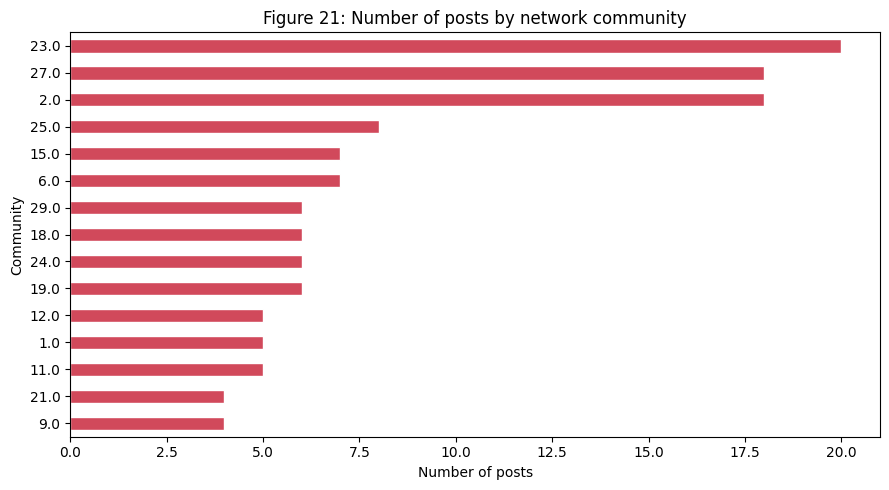

In [ ]:
top_communities = community_post_counts.head(15)

fig, ax = plt.subplots(figsize=(9, 5))

top_communities.sort_values().plot(
    kind="barh",
    ax=ax,
    color=POST_COLOR,
    edgecolor="white"
)

ax.set_title("Figure 21: Number of posts by network community", fontsize=12)
ax.set_xlabel("Number of posts")
ax.set_ylabel("Community")

plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig21_posts_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

Community sizes are highly uneven. A small number of communities (23, 27, 2) account for the majority of posts, while most remaining communities contain fewer than 10. This distribution is typical of online discussion networks and suggests that the bulk of the debate was concentrated in a limited number of active clusters.

### **7.4 Subreddit composition by community**

To evaluate the institutional nature of these interaction clusters, we calculate the proportion of posts contributed by each subreddit to each community, uncovering whether network partitions match the platform's formal forum boundaries.

In [ ]:
community_subreddit = pd.crosstab(
    df_posts_comm_filtered["community"],
    df_posts_comm_filtered["subreddit"],
    normalize="index"
)

community_subreddit

subreddit,Screenwriting,artificial,movies,television
community,,,,
1.0,0.800000,0.000000,0.000000,0.200000
2.0,1.000000,0.000000,0.000000,0.000000
6.0,0.857143,0.142857,0.000000,0.000000
11.0,0.000000,0.000000,1.000000,0.000000
12.0,0.000000,1.000000,0.000000,0.000000
15.0,0.000000,0.000000,0.571429,0.428571
18.0,0.000000,0.000000,0.833333,0.166667
19.0,0.000000,0.000000,0.166667,0.833333
23.0,0.000000,1.000000,0.000000,0.000000


The subreddit composition already reveals meaningful differences between communities. Several communities are almost entirely associated with a single subreddit, suggesting that interaction patterns often remain concentrated within the same thematic space.

Communities 2, 24, and 25 are composed exclusively of users from `r/Screenwriting`, while communities 12 and 23 are entirely associated with `r/artificial`. Community 11 is exclusively linked to r/movies. Other communities exhibit a more heterogeneous composition. For example, community 6 is primarily dominated by `r/Screenwriting` users but also includes a small presence from `r/artificial`, whereas communities 15, 18, 27, and 29 combine users from both r/movies and `r/television`. Community 19 is largely television-oriented, with more than 80% of its users originating from `r/television`. Overall, the results suggest that while many interaction clusters remain strongly tied to a specific discussion space, some communities bridge multiple entertainment-related subreddits and facilitate cross-community interaction.

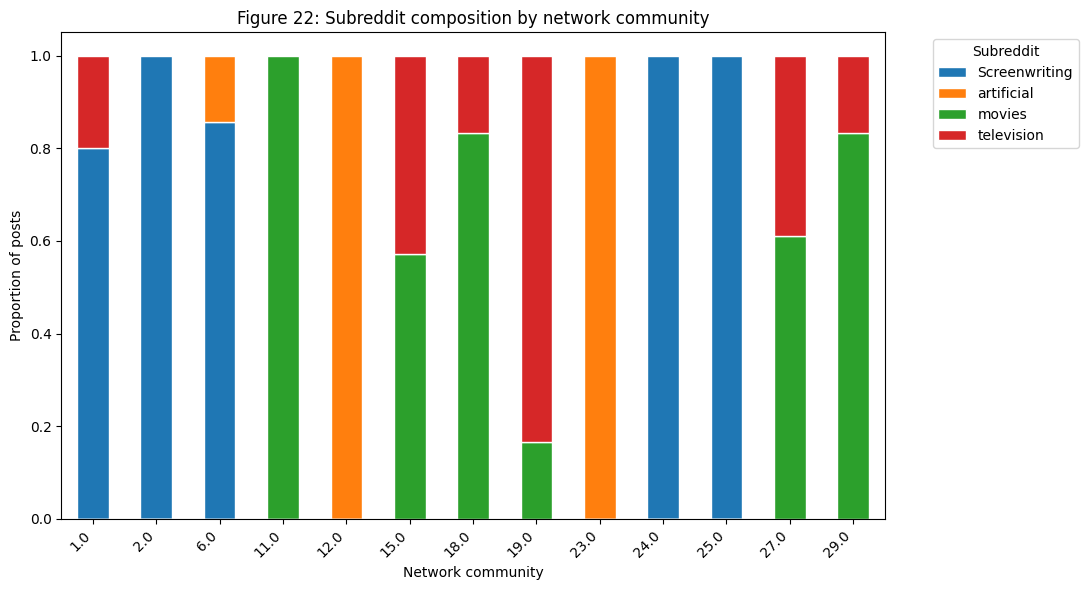

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

community_subreddit.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="white"
)

ax.set_title("Figure 22: Subreddit composition by network community", fontsize=12)
ax.set_xlabel("Network community")
ax.set_ylabel("Proportion of posts")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Subreddit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(DRIVE_PATH_IMAGES + "fig22_community_subreddit_composition.png", dpi=150, bbox_inches="tight")
plt.show()

The visualization indicates that most network communities align closely with subreddit boundaries. This suggests that the structure of Reddit discussions plays an important role in shaping interaction patterns around AI and the Hollywood Strike.

Nevertheless, several mixed communities emerge, particularly between `r/movies` and `r/television`. These clusters suggest that discussions were not completely isolated within individual subreddits and that some interaction occurred across related entertainment-focused communities.

### **7.5 Frame Distribution by Network Community**

This section connects network structure and content analysis by examining how dominant frames are distributed across network communities.

The goal is to assess whether interaction communities show different frame-related vocabularies when discussing AI during the Hollywood Strike. Since the frame labels are based on dictionary matching, the results should be interpreted as patterns of lexical association rather than definitive semantic classifications.

To make the comparison more interpretable, only communities with enough posts to support meaningful comparison are considered.

The following analysis computes the proportional distribution of dominant frames inside each network community. A normalized contingency table is constructed where rows correspond to communities and columns correspond to dominant interpretive frames. Posts labeled as `unclassified` or `mixed` are excluded from this visualization to focus on clearer frame assignments.

In [ ]:
community_frame_dist = pd.crosstab(
    df_posts_comm["community"],
    df_posts_comm["dominant_frame"],
    normalize="index"
)

# Remove unclassified and mixed for clarity
community_frame_dist = community_frame_dist.drop(
    columns=["unclassified", "mixed"],
    errors="ignore"
)

community_frame_dist = community_frame_dist.fillna(0)

print("Frame distribution by community:")
community_frame_dist.head(10)

Frame distribution by community:


dominant_frame,authenticity_creativity,corporate_power,innovation_opportunity,replacement_anxiety,workers_rights
community,,,,,
0.0,0.333333,0.000000,0.333333,0.000000,0.000000
1.0,0.600000,0.000000,0.000000,0.000000,0.200000
2.0,0.333333,0.555556,0.000000,0.055556,0.000000
3.0,0.666667,0.000000,0.000000,0.000000,0.000000
4.0,0.000000,0.000000,0.000000,0.000000,1.000000
5.0,0.333333,0.000000,0.333333,0.000000,0.000000
6.0,0.285714,0.285714,0.142857,0.142857,0.000000
7.0,0.500000,0.500000,0.000000,0.000000,0.000000
8.0,0.000000,0.333333,0.000000,0.000000,0.333333


The frame distribution table shows variation across network communities. Some communities are strongly concentrated around one frame, while others display a more mixed distribution.

However, several communities contain relatively few posts, so high proportions should be interpreted cautiously. A value of 1.00 may indicate a clearly concentrated frame, but it may also reflect a small number of posts within that community.

The proportional distributions are visualized as a heatmap. Darker cells indicate that a larger proportion of posts within a community are associated with a given frame.

This visualization connects interaction structure and discourse structure by showing whether different network communities tend to be associated with different frame categories.

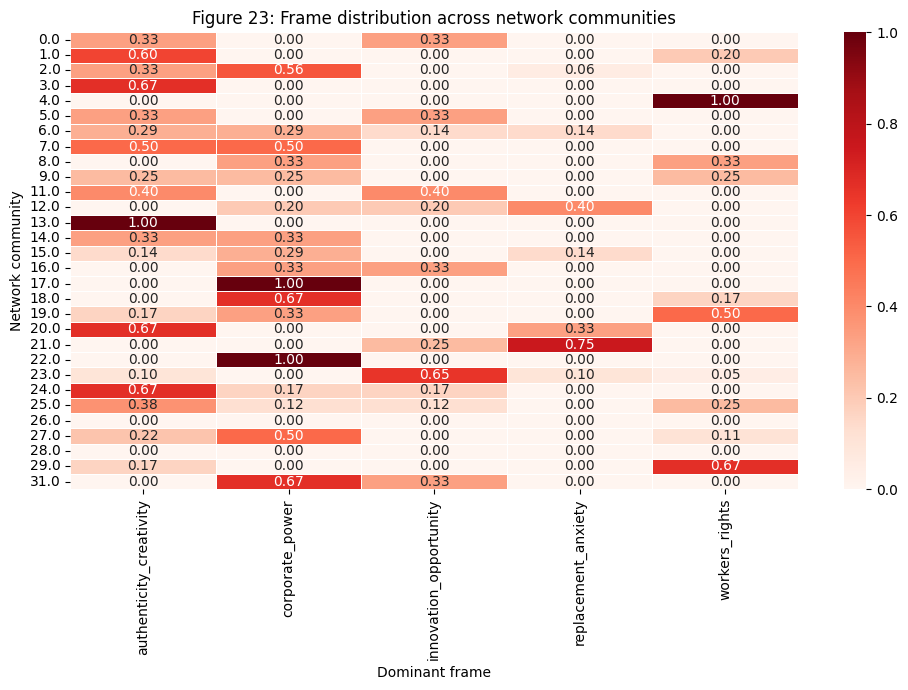

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    community_frame_dist,
    annot=True,
    cmap="Reds",
    linewidths=0.5,
    fmt=".2f",
    ax=ax
)

ax.set_title("Figure 23: Frame distribution across network communities", fontsize=12)
ax.set_xlabel("Dominant frame")
ax.set_ylabel("Network community")

plt.tight_layout()
plt.savefig(
    DRIVE_PATH_IMAGES + "fig23_frame_by_community_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

The heatmap shows that AI framing during the Hollywood Strike was strongly community-dependent rather than uniformly distributed. Communities 13, 17, 22, and 4 score 1.00 on a single frame, suggesting tight ideological homophily, likely driven by Reddit's subreddit structure, where pre-existing professional or ideological ties reinforce a shared narrative lens.

`Replacement_anxiety` and `workers_rights` are notably sparse and concentrated in just a few clusters (specifically communities 21 and 12), implying that explicit labor-focused discourse did not diffuse broadly across the network but remained siloed. Meanwhile, communities like 6, 15, and 25 show distributed scores across multiple frames, hinting at more generalist audiences where economic and identity-level concerns coexist.
Overall, the network did not simply split into "pro-AI" vs "anti-AI" camps; it fragmented along more nuanced discursive lines shaped by community identity.


For interpretive clarity, each community is assigned a single main frame corresponding to the most frequent frame among its posts. This is a simplified summary of each community’s dominant frame-related vocabulary, not a definitive label of the community’s identity or ideology.

In [ ]:
community_main_frame = (
    community_frame_dist.idxmax(axis=1)
    .reset_index(name="main_frame")
)

community_main_frame = community_main_frame.merge(
    community_post_counts.reset_index(),
    on="community"
)

community_main_frame.columns = [
    "community",
    "main_frame",
    "num_posts"
]

community_main_frame = community_main_frame.sort_values(
    "num_posts",
    ascending=False
)

community_main_frame.head(15)

,community,main_frame,num_posts
22,23.0,innovation_opportunity,20
2,2.0,corporate_power,18
26,27.0,corporate_power,18
24,25.0,authenticity_creativity,8
14,15.0,corporate_power,7
6,6.0,authenticity_creativity,7
28,29.0,workers_rights,6
18,19.0,workers_rights,6
17,18.0,corporate_power,6
23,24.0,authenticity_creativity,6


The largest communities are associated with different main frames. Community 23 is mainly linked to innovation and opportunity, while communities 2 and 27 are mainly associated with corporate power. Other sizeable communities are associated with authenticity and creativity, workers’ rights, or replacement anxiety. This suggests that larger interaction clusters did not all organize around the same interpretation of AI. Instead, different communities appear to emphasize different aspects of the debate.

The following chart summarizes how many network communities are mainly associated with each frame. This shifts the analysis from individual posts to the community level, showing which frame categories most frequently characterize the detected interaction clusters.

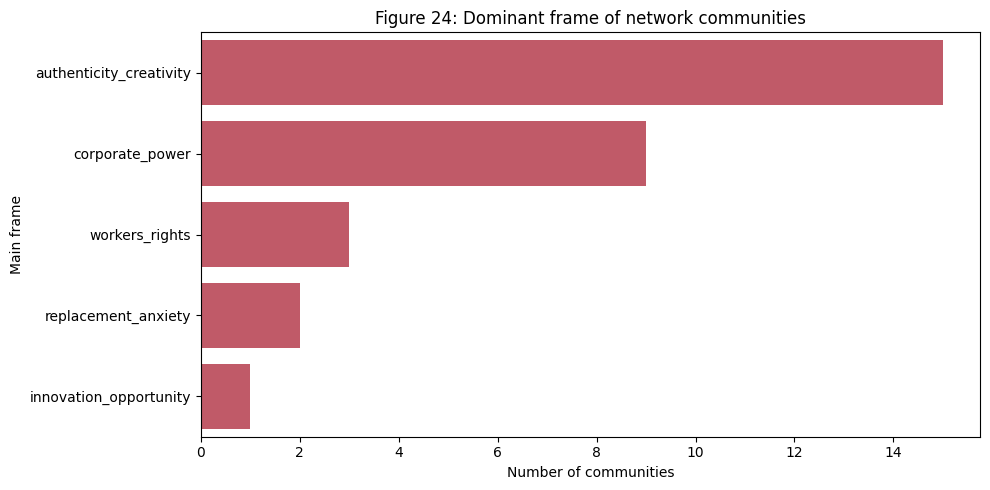

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(
    data=community_main_frame,
    y="main_frame",
    order=community_main_frame["main_frame"].value_counts().index,
    color=POST_COLOR
)

ax.set_title(
    "Figure 24: Dominant frame of network communities",
    fontsize=12
)

ax.set_xlabel("Number of communities")
ax.set_ylabel("Main frame")

plt.tight_layout()

plt.savefig(
    DRIVE_PATH_IMAGES + "fig24_main_frame_communities.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

At the community level, authenticity and creativity is the most common main frame, followed by corporate power. Workers’ rights, replacement anxiety, and innovation and opportunity appear less frequently as the dominant frame of entire communities. This suggests that many Reddit communities in the dataset were primarily associated with concerns about human creativity, artistic authorship, and institutional power. However, because the chart counts communities rather than posts, it should be read as a summary of community-level orientation rather than as a measure of overall discourse volume.

### **7.6 Brokers and Mixed Framing**
One of the project's exploratory questions is whether structurally central users also show more diverse framing behavior. Users with high betweenness centrality occupy intermediary positions in the interaction network and may be exposed to a wider range of discussions. To test this, the number of distinct dominant frames associated with each author's posts is computed and compared against their betweenness centrality score. This is an exploratory analysis: frame diversity does not prove intentional mediation between perspectives, but provides a preliminary indication of whether brokerage and discursive breadth co-occur in this network.

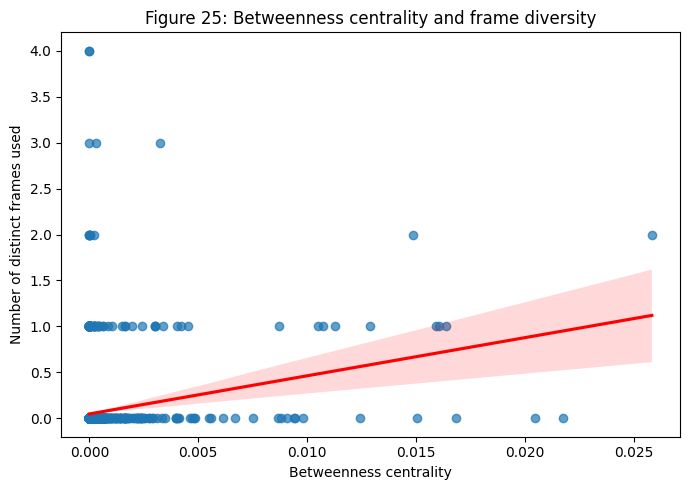

In [ ]:
author_frame_diversity = (
    df.groupby("author")["dominant_frame"]
    .nunique()
    .reset_index(name="frame_diversity")
)

# Merge with centrality metrics
broker_analysis = network_users_df.merge(
    author_frame_diversity,
    left_on="user",
    right_on="author",
    how="left"
)

broker_analysis["frame_diversity"] = (
    broker_analysis["frame_diversity"]
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(7, 5))

sns.regplot(
    data=broker_analysis,
    x="betweenness_centrality",
    y="frame_diversity",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"},
    ax=ax
)

ax.set_title(
    "Figure 25: Betweenness centrality and frame diversity",
    fontsize=12
)

ax.set_xlabel("Betweenness centrality")
ax.set_ylabel("Number of distinct frames used")

plt.tight_layout()

plt.savefig(
    DRIVE_PATH_IMAGES + "fig25_broker_frame_diversity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

The relationship between betweenness centrality and frame diversity is weakly positive but not strong across the network. Most users, regardless of their structural position, are associated with zero or one distinct frame. A small number of high-betweenness users show greater frame diversity, but this remains the exception rather than the rule. High betweenness centrality identifies structurally important users, but does not systematically imply exposure to or mediation between different discursive orientations. The stronger conclusion from this section is that community membership, rather than individual brokerage, is the primary driver of framing patterns in this network.

## **Conclusion**
This project investigated how online communities framed the role of artificial intelligence during the Hollywood Strike of 2023, drawing on 255 Reddit submissions and 7,988 comments collected across five subreddits over a ten-month period.

The analysis converges on three main findings.

First, AI framing during the Hollywood Strike was not uniform but strongly community-dependent. `r/Screenwriting` consistently emphasized authenticity and creativity and workers' rights, reflecting the professional stakes of its users. `r/artificial` framed AI primarily as an innovation opportunity, with minimal negative sentiment and references centered on technology companies rather than labor organizations. Entertainment communities such as `r/movies` and `r/television` occupied an intermediate position, combining corporate power concerns with audience-level perspectives. These differences were stable across frame detection, sentiment analysis, and named entity recognition, providing convergent evidence that community identity shaped both the interpretive lens and the emotional tone of AI discourse.

Second, the network analysis revealed a strongly segmented interaction structure. The Louvain community detection algorithm identified communities that closely mirror subreddit boundaries, with a high modularity score (0.8672) indicating that users interacted far more within their own communities than across them. Cross-subreddit interaction declined steadily across phases, from 15.5% before the strike to 12.4% in the post-strike period, suggesting that the conflict reinforced rather than dissolved community boundaries. Degree assortativity was negative across all phases but became progressively less so over time (−0.30 pre-strike, −0.11 post-strike), suggesting that the hub-and-spoke interaction structure gradually gave way to a more distributed conversational core as the debate matured.

Third, the temporal evolution of the discourse did not follow a simple mobilization-and-resolution pattern. Corporate power framing peaked during the strike itself, while negative sentiment peaked in the post-strike phase, particularly in September and October 2023, as users scrutinized the AI protection clauses of the final contracts. This suggests that the formal resolution of the labor dispute did not defuse underlying anxieties about AI in creative industries but redirected them toward longer-term concerns about enforcement and institutional accountability.

Some limitations should be acknowledged. The corpus relies on PullPush, an unofficial Reddit archive subject to availability gaps, which may have introduced partial coverage for some subreddits and time windows. Frame detection is based on dictionary matching without TF-IDF weighting, and results should be interpreted as indicative rather than precise. The pre-strike phase is underrepresented relative to the strike and post-strike phases, which limits the depth of longitudinal comparisons involving that period.

Future work could extend this analysis by tracking how AI framing in creative industries evolved after the strike settlements, or by applying topic modeling alongside dictionary-based frame detection to capture latent thematic structure not captured by predefined categories.